# Analysis — leave-one-out, visualization, regression, Bayesian optimization, LVGP, trees

Consumes `output/master_df.pkl` produced by `data_pipeline.ipynb`. Run the data_pipeline notebook first.


In [1]:
# --- preamble: ensure relative paths resolve to repository_dmref root ---
import os
if os.path.basename(os.getcwd()) != 'repository_dmref':
    os.chdir('..')
print('cwd =', os.getcwd())


cwd = /data/zhq7531/IDEAL/DMREF/repository_dmref


In [2]:
# --- preamble: load master_df produced by data_pipeline notebook ---
import pandas as pd
master_df = pd.read_pickle('output/master_df.pkl')
print('loaded master_df with shape', master_df.shape)


loaded master_df with shape (51, 42)


# Leave one out

In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

target = "Hall Mobility (cm^2/V·s)"

# Same process predictors you used before
process_predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]

# -------------------------------------------------
# Build modeling dataframe with Experiment column
# -------------------------------------------------
cols_needed = ["Experiment"] + process_predictors + [target]
df_all = master_df[cols_needed].dropna().copy()

print("Number of rows used for CV:", len(df_all))
print("Experiments:", sorted(df_all["Experiment"].unique()))

# -------------------------------------------------
# Rebuild the SAME formula as in your main model
# -------------------------------------------------
main_terms = [
    "Q('Power (W)')",
    "Q('Substrate Temp (°C)')",
    "Q('O2 Flow (sccm)')",
    "Q('Pressure (mTorr)')",
    "Q('Anneal Temp (°C)')",
    # Anneal Condition only appears through interaction
]

interaction_terms = [
    "Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)')",     # Substrate Temp × O2 Flow
    "Q('Power (W)'):Q('O2 Flow (sccm)')",              # Power × O2 Flow
    "Q('Power (W)'):C(Q('Anneal Condition Num'))",     # Power × Anneal Condition (categorical)
]

rhs = " + ".join(main_terms + interaction_terms)
formula = f"Q('{target}') ~ {rhs}"
print("Formula used for CV:")
print(formula)

# -------------------------------------------------
# Leave-one-experiment-out CV
# -------------------------------------------------
results = []

for exp_id in sorted(df_all["Experiment"].unique()):
    # split train / test by experiment
    df_train = df_all[df_all["Experiment"] != exp_id]
    df_test = df_all[df_all["Experiment"] == exp_id]

    # fit on training experiments
    model_cv = smf.ols(formula=formula, data=df_train).fit()

    # predict for held-out experiment
    y_test = df_test[target]
    y_pred = model_cv.predict(df_test)

    # metrics
    mse = np.mean((y_test - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2_test = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    results.append({
        "Held_out_experiment": exp_id,
        "n_test": len(df_test),
        "RMSE": rmse,
        "MAE": mae,
        "R2_test": r2_test,
    })

cv_df = pd.DataFrame(results)
display(cv_df)

print("\nAverage across folds:")
print(cv_df[["RMSE", "MAE", "R2_test"]].mean())


Number of rows used for CV: 46
Experiments: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17)]
Formula used for CV:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)') + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):C(Q('Anneal Condition Num'))


,Held_out_experiment,n_test,RMSE,MAE,R2_test
0,1,3,44.631284,39.849175,-3.930637
1,2,2,38.686787,38.470512,-88.689419
2,3,3,16.538090,16.472656,-125.624265
3,4,3,37.884022,37.802546,-231.734996
4,5,3,65.072673,65.064999,-4239.011958
5,6,3,20.739020,20.396919,-29.563383
6,7,3,21.256781,21.112991,-73.166835
7,8,3,41.926428,41.883867,-491.789905
8,9,3,24.707340,24.131662,-20.712274
9,10,3,12.961895,12.543838,-14.756620



Average across folds:
RMSE        27.018889
MAE         26.221934
R2_test   -792.120916
dtype: float64


# Visualization

## Noise on the data (calc coefficient of variation)

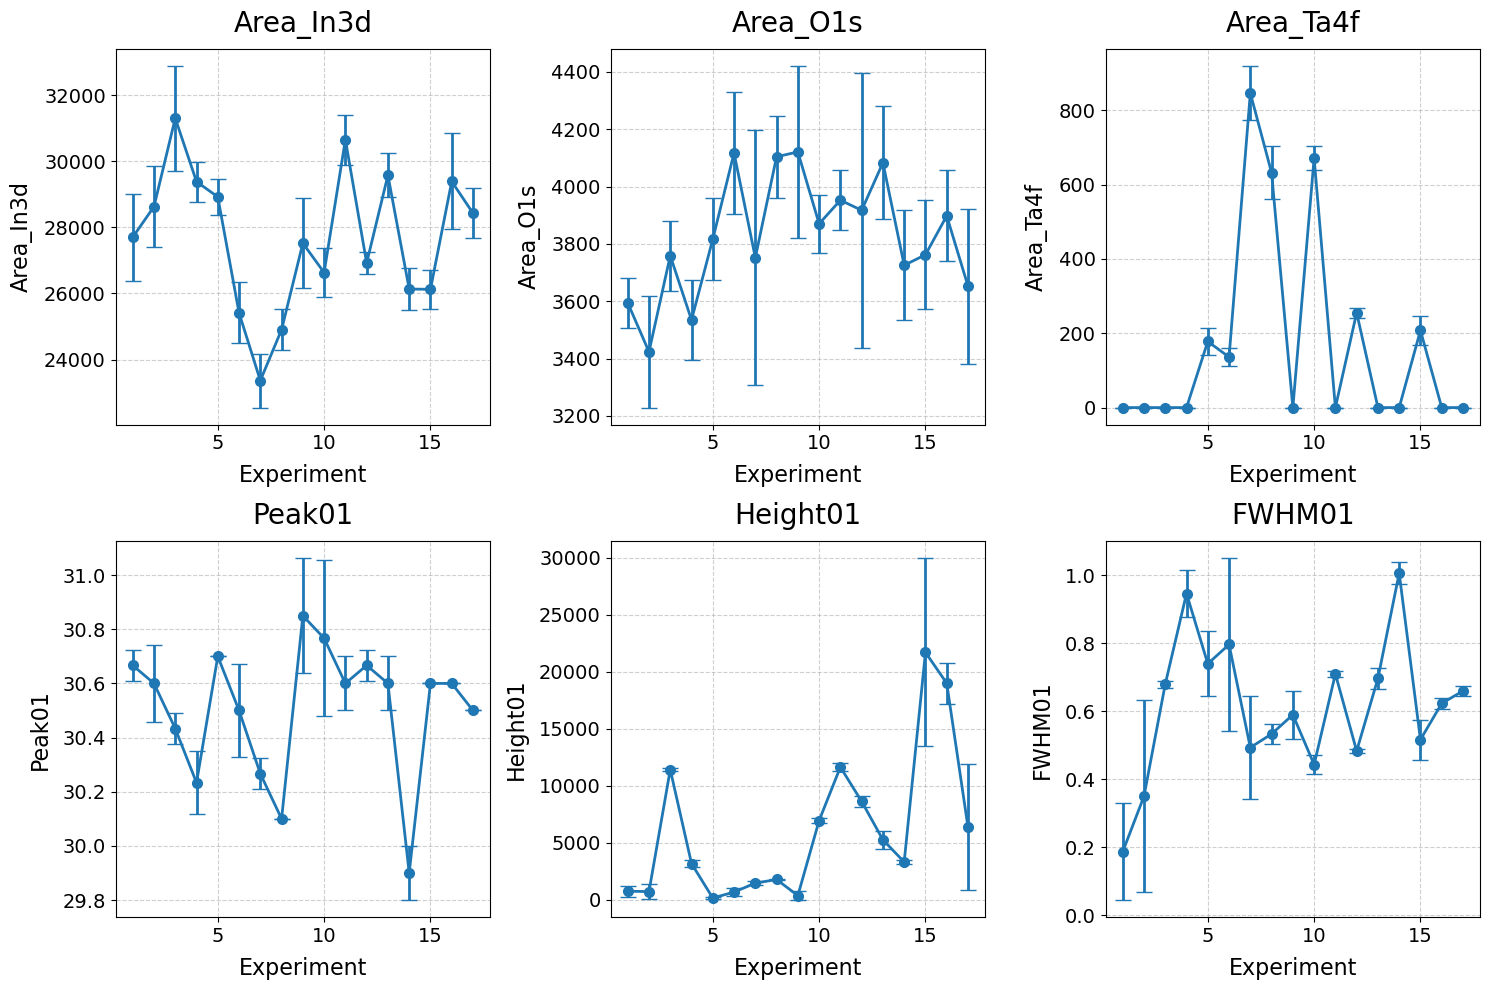

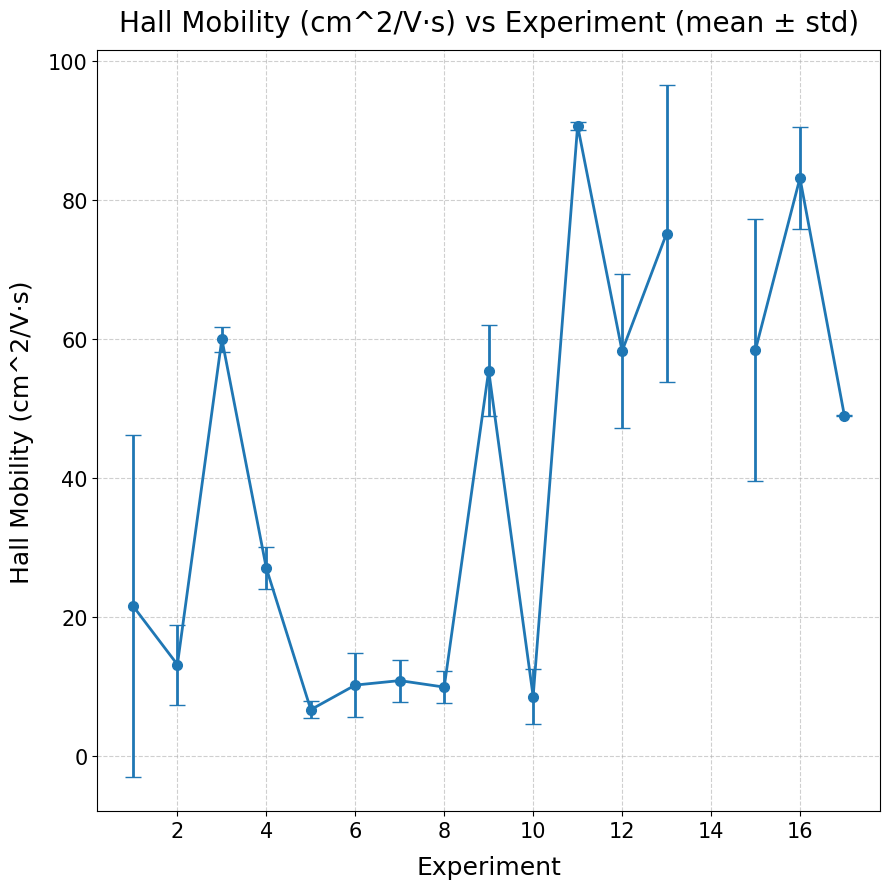

Coefficient of variation per experiment (percent):


,CV_%_Area_In3d,CV_%_Area_O1s,CV_%_Area_Ta4f,CV_%_Peak01,CV_%_Height01,CV_%_FWHM01,CV_%_Hall Mobility (cm^2/V·s)
Experiment,,,,,,,
1,4.762,2.454,nan,0.188,61.957,76.202,114.108
2,4.295,5.680,nan,0.462,92.257,80.812,44.049
3,5.074,3.237,nan,0.190,1.339,1.471,3.000
4,2.043,3.940,nan,0.382,9.652,7.190,11.264
5,1.916,3.764,20.419,0.000,34.032,12.891,18.470
6,3.639,5.132,17.890,0.568,56.718,31.862,45.191
7,3.497,11.835,8.691,0.191,11.845,30.764,27.956
8,2.481,3.469,11.211,0.000,4.629,5.728,23.420
9,4.953,7.291,nan,0.688,105.509,11.985,11.708


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) columns we want to analyze
cols_to_agg = [
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Peak01",
    "Height01",
    "FWHM01",
    "Hall Mobility (cm^2/V·s)",
]

# keep only those that exist
cols_to_agg = [c for c in cols_to_agg if c in master_df.columns]

# 2) group by experiment and compute mean and std
grp_mean = master_df.groupby("Experiment")[cols_to_agg].mean(numeric_only=True)
grp_std = master_df.groupby("Experiment")[cols_to_agg].std(numeric_only=True)

# separate hall mobility if present
hall_col = "Hall Mobility (cm^2/V·s)"
has_hall = hall_col in cols_to_agg

# variables to plot in the 3x2 grid (exclude hall mobility)
grid_cols = [c for c in cols_to_agg if c != hall_col]

# 3) make a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, grid_cols):
    x = grp_mean.index.values
    y = grp_mean[col].values
    yerr = grp_std[col].values

    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    ax.set_title(col, fontsize=20, pad=12)
    ax.set_xlabel("Experiment", fontsize=16, labelpad=8)
    ax.set_ylabel(col, fontsize=16, labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)

# hide any unused axes
for i in range(len(grid_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# 3b) plot hall mobility separately
if has_hall:
    plt.figure(figsize=(9, 9))
    x = grp_mean.index.values
    y = grp_mean[hall_col].values
    yerr = grp_std[hall_col].values
    plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    plt.title(f"{hall_col} vs Experiment (mean ± std)", fontsize=20, pad=14)
    plt.xlabel("Experiment", fontsize=18, labelpad=10)
    plt.ylabel(hall_col, fontsize=18, labelpad=10)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 4) coefficient of variation (CV = std / mean) as PERCENT
cv_df = (grp_std / grp_mean.replace(0, np.nan)) * 100
cv_df = cv_df.add_prefix("CV_%_")

print("Coefficient of variation per experiment (percent):")
display(
    cv_df.style.format("{:.3f}").background_gradient(cmap="Blues")
)
cv_df.to_excel("output/cv_percetage.xlsx", index_label=False)


In [5]:
hall_col = "Hall Mobility (cm^2/V·s)"

# 1) Design table: one row per experiment with the knob settings
design_cols = [
    "Experiment",
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

design_df = (
    master_df[design_cols]
    .drop_duplicates(subset="Experiment")
    .set_index("Experiment")
)

# 2) Mean and std of Hall mobility per experiment
hall_mean = grp_mean[[hall_col]].rename(
    columns={hall_col: "Hall mobility mean (cm^2/V·s)"}
)
hall_std = grp_std[[hall_col]].rename(
    columns={hall_col: "Hall mobility std (cm^2/V·s)"}
)

# 3) Merge into a single summary table
summary = design_df.join(hall_mean).join(hall_std).reset_index()

# 4) Save to Excel
summary.to_excel("output/experiment_hall_stats.xlsx", index=False)

print(summary)


    Experiment  Power (W)  Substrate Temp (°C)  O2 Flow (sccm)  \
0            1         10                   25             0.3   
1            2         10                   25             0.3   
2            3         10                  400             3.0   
3            4         10                  400             3.0   
4            5         30                   25             3.0   
5            6         30                   25             3.0   
6            7         30                  400             0.3   
7            8         30                  400             0.3   
8            9         20                   25             3.0   
9           10         30                   25             0.3   
10          11         20                  400             2.0   
11          12         20                  400             0.3   
12          13         10                   25             2.0   
13          14         20                   25             2.0   
14        

In [6]:
# build a per-trial dataset with knobs + Hall mobility
cols = design_cols + [hall_col]   # from your code
df_trials = master_df[cols].dropna(subset=[hall_col]).copy()


## correlation matrix 

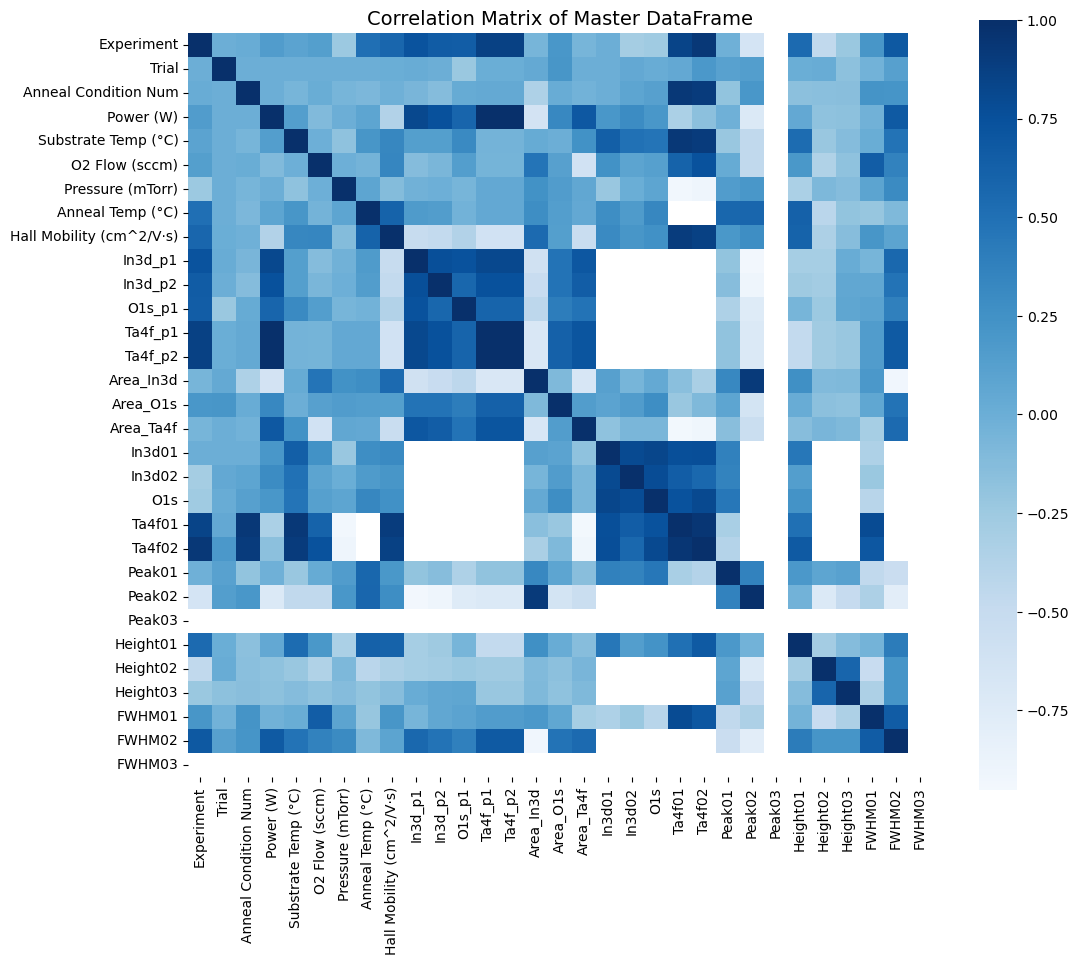

                            Experiment         Trial  Anneal Condition Num  \
Experiment                1.000000e+00  1.567374e-16          2.405626e-02   
Trial                     1.567374e-16  1.000000e+00          5.341563e-18   
Anneal Condition Num      2.405626e-02  5.341563e-18          1.000000e+00   
Power (W)                 1.572070e-01  9.647018e-17          1.121270e-16   
Substrate Temp (°C)       9.622504e-02  0.000000e+00         -5.555556e-02   
O2 Flow (sccm)            1.341852e-01  4.655484e-18          1.271023e-02   
Pressure (mTorr)         -2.405626e-01  3.204938e-17         -5.555556e-02   
Anneal Temp (°C)          5.062618e-01  6.573185e-17         -8.076445e-02   
Hall Mobility (cm^2/V·s)  5.746485e-01  2.150887e-03         -1.955583e-02   
In3d_p1                   7.318114e-01  2.245854e-02         -6.032431e-02   
In3d_p2                   6.638303e-01 -1.335720e-14         -1.343016e-01   
O1s_p1                    6.536818e-01 -2.285297e-01          2.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns from your master_df
df_corr = master_df.select_dtypes(include=["number"]).copy()

# Compute correlation matrix (Pearson by default)
corr_matrix = df_corr.corr()

# Display as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    # annot=True,       # show correlation values
    cmap="Blues",  # color palette
    center=0,
    fmt=".2f",
    square=True,
)
plt.title("Correlation Matrix of Master DataFrame", fontsize=14)
plt.show()

# Optional: save to Excel for exploration
# corr_matrix.to_excel("correlation_matrix.xlsx")
print(corr_matrix)


## Pair plots

Numeric columns used in pair plot:
['Experiment', 'Trial', 'Anneal Condition Num', 'Power (W)', 'Substrate Temp (°C)', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Hall Mobility (cm^2/V·s)', 'In3d_p1', 'In3d_p2', 'O1s_p1', 'Ta4f_p1', 'Ta4f_p2', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'In3d01', 'In3d02', 'O1s', 'Ta4f01', 'Ta4f02', 'Peak01', 'Peak02', 'Peak03', 'Height01', 'Height02', 'Height03', 'FWHM01', 'FWHM02', 'FWHM03']


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


<Figure size 1800x1800 with 0 Axes>

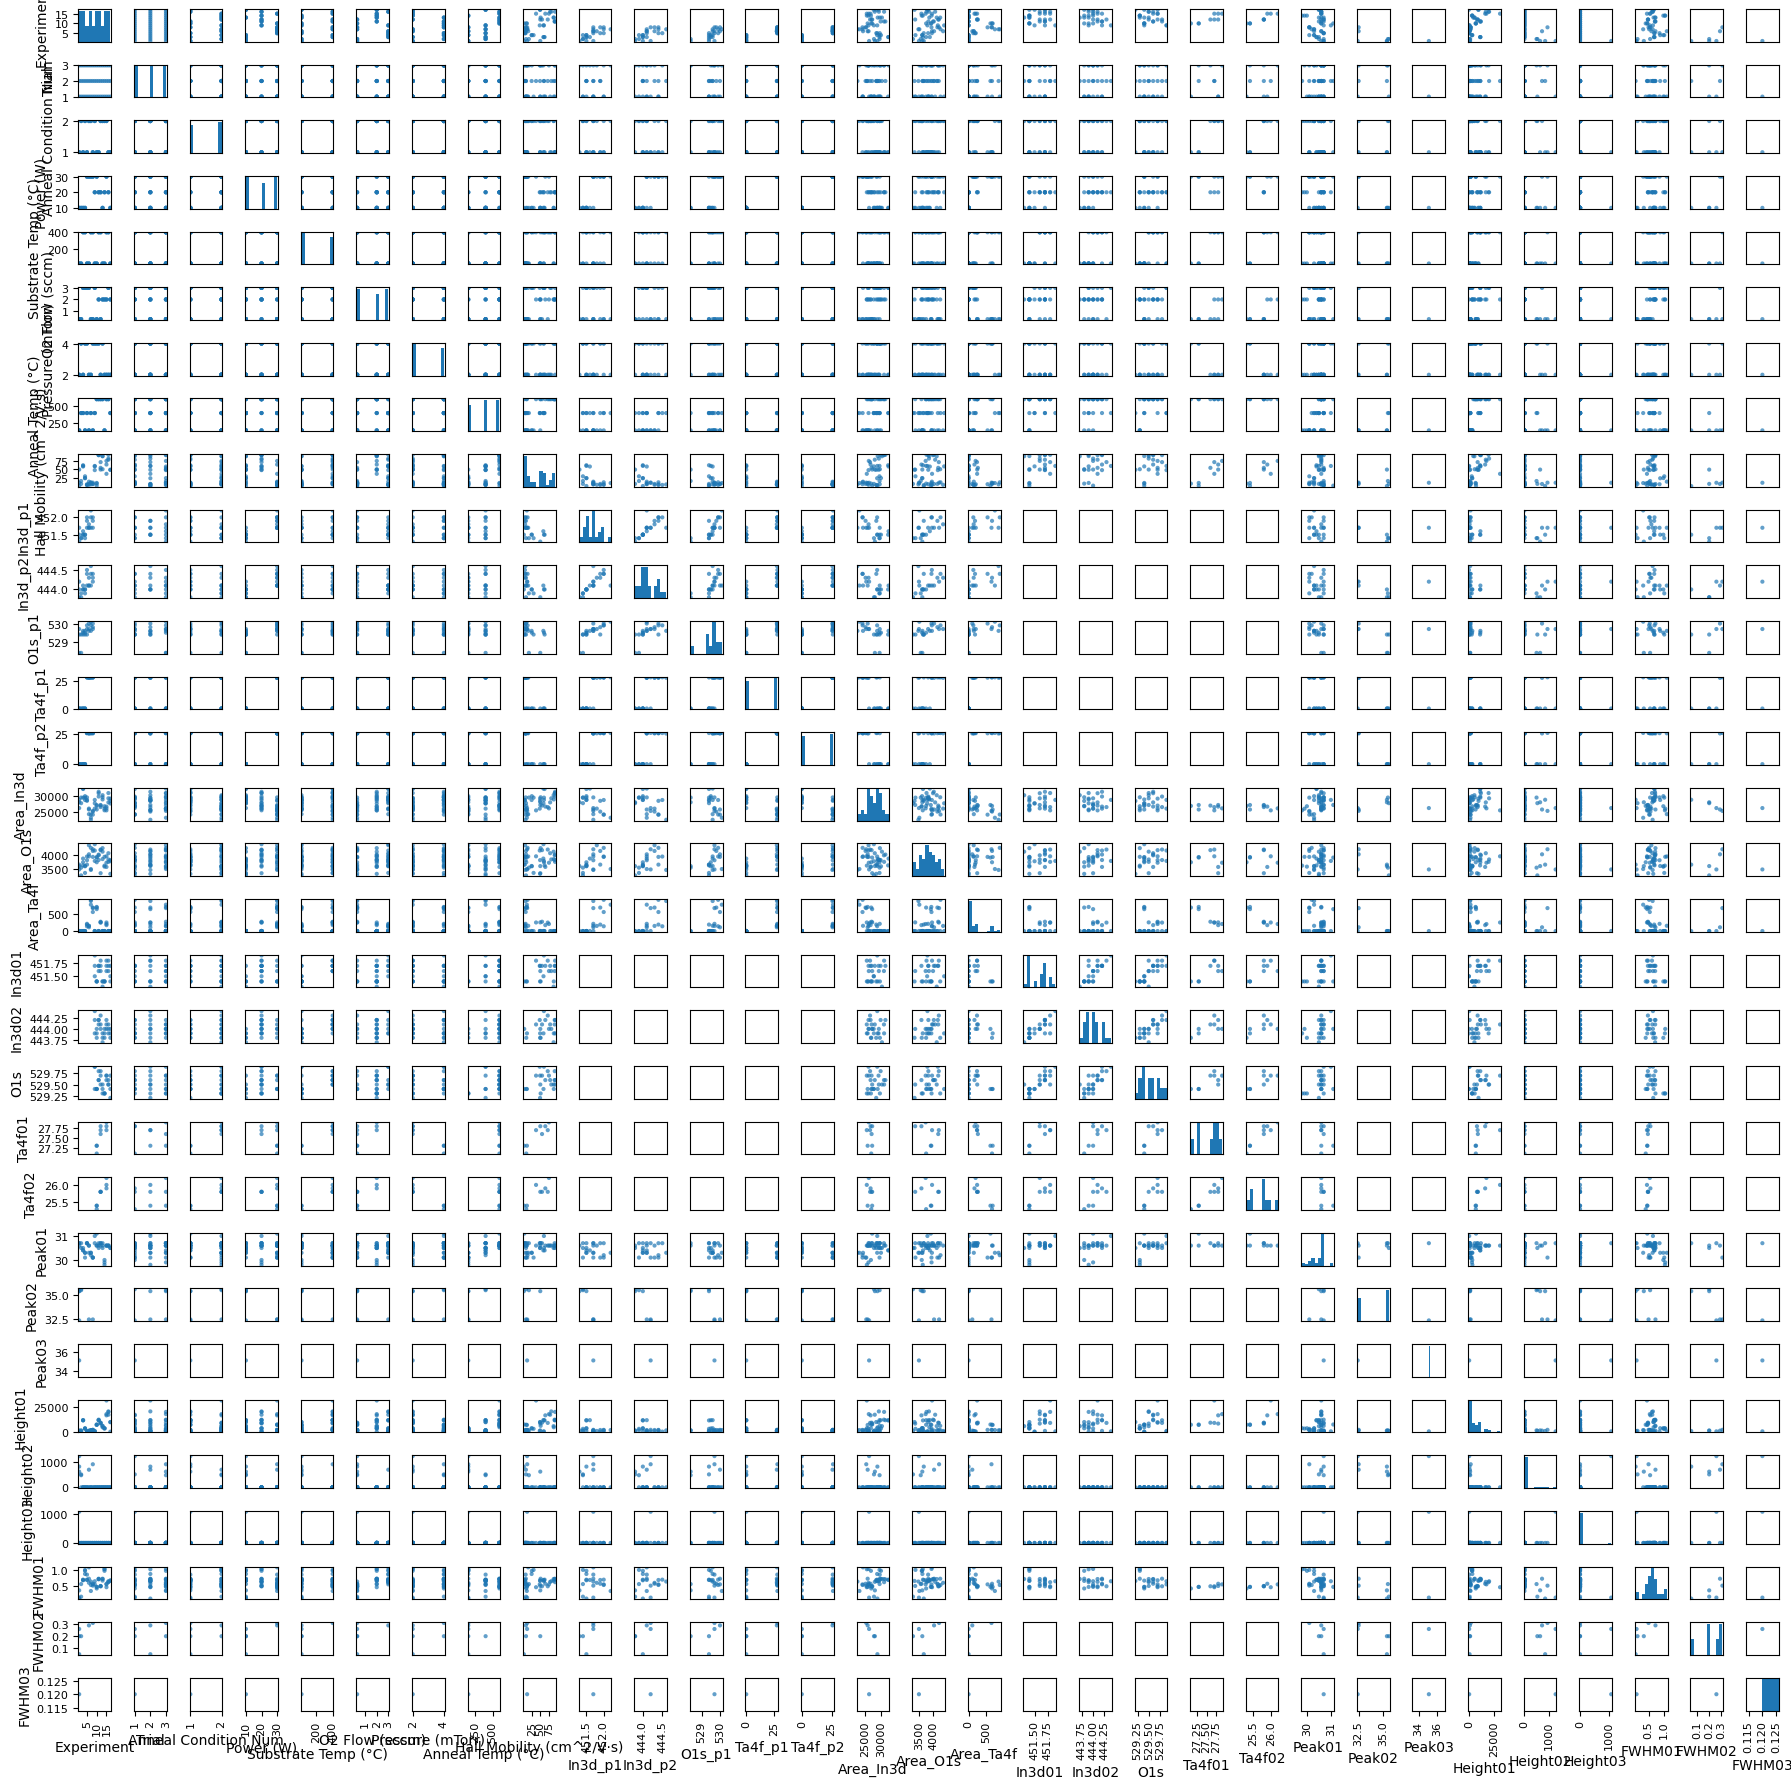

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# 1) pick only numeric columns from master_df
num_df = master_df.select_dtypes(include=[np.number]).copy()

print("Numeric columns used in pair plot:")
print(num_df.columns.tolist())

# 2) make a big scatter-matrix (pair plot)
plt.figure(figsize=(18, 18))
axes = scatter_matrix(
    num_df,
    diagonal='hist',
    alpha=0.7,
    figsize=(18, 18),
)

# make tick labels a bit smaller
for ax in axes.flatten():
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()


Columns in pair plot (in order):
['Hall Mobility (cm^2/V·s)', 'Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']


<Figure size 3000x3000 with 0 Axes>

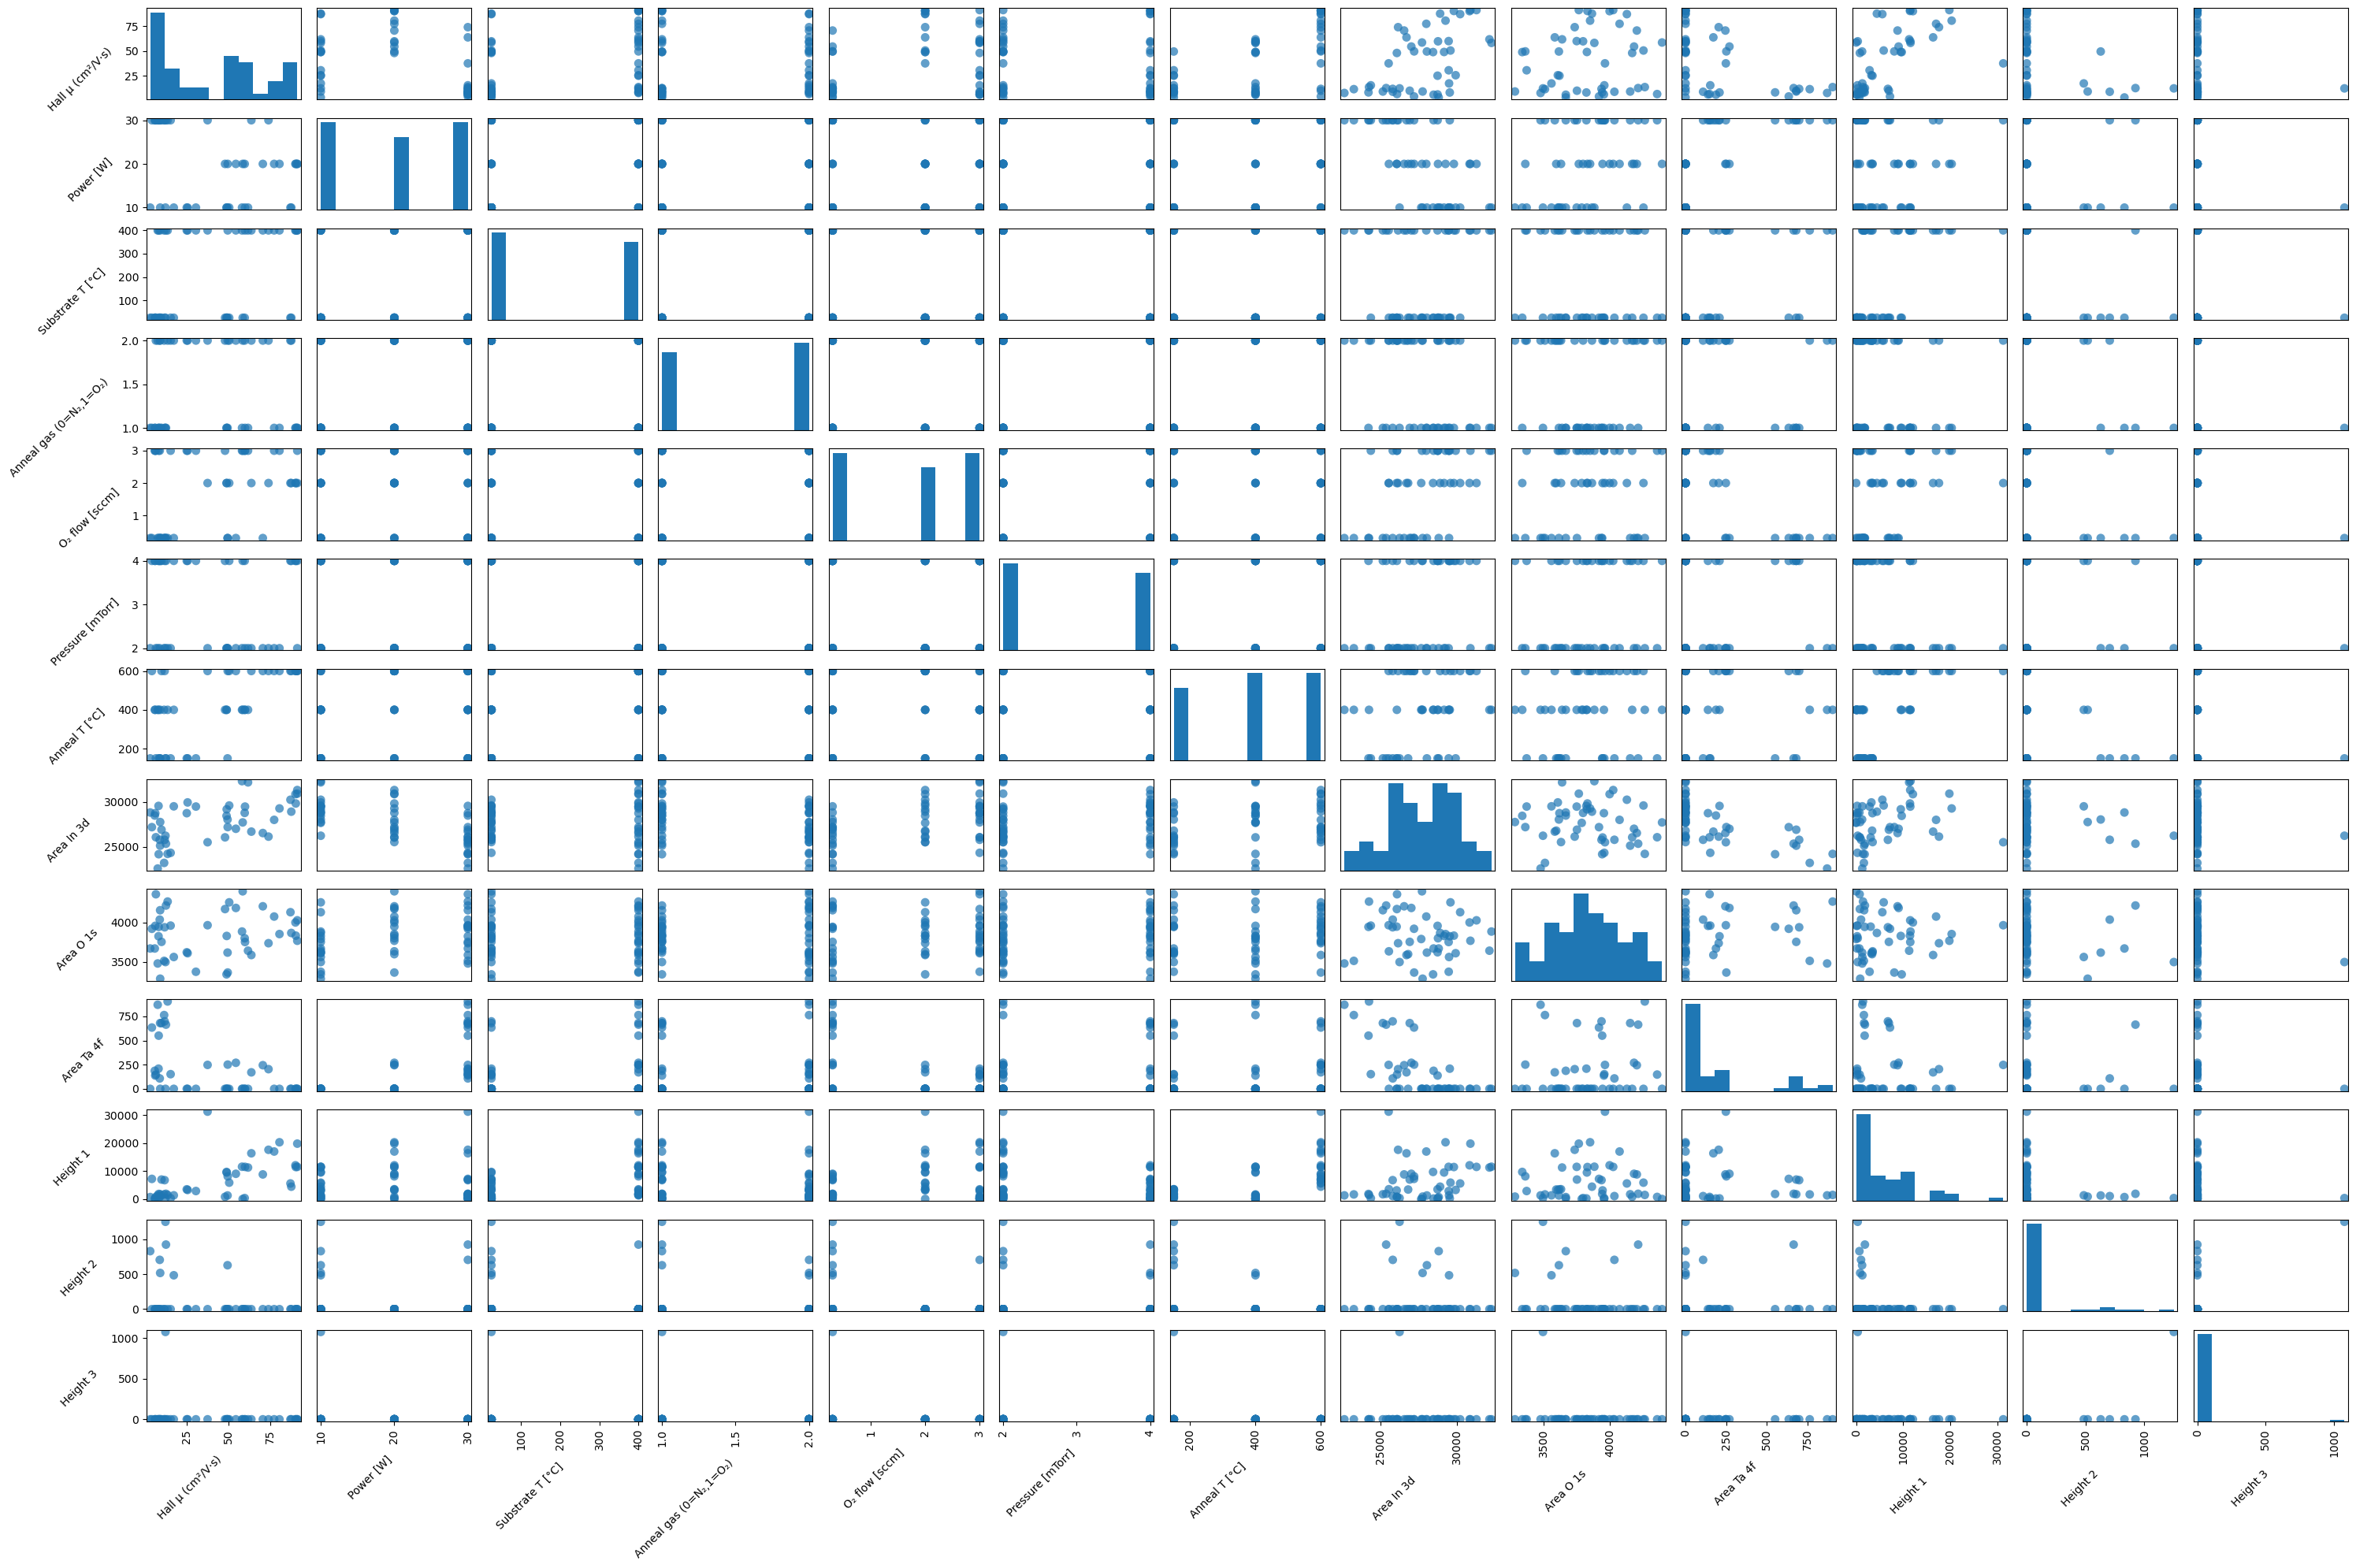

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# 1) name of your target
target_col = "Hall Mobility (cm^2/V·s)"

# 2) choose the predictors you care about (order after the target)
predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    # "In3d_p1", 
    # "In3d_p2", 
    # "O1s_p1", 
    # "Ta4f_p1", 
    # "Ta4f_p2",
    # "Peak01", 
    # "Peak02",
    # "Peak03", 
    "Height01",
    "Height02", 
    "Height03", 
    # "FWHM01", 
    # "FWHM02", 
    # "FWHM03",
]

# keep only those that actually exist in master_df
predictors = [c for c in predictors if c in master_df.columns]

# 3) put Hall mobility first, then predictors
cols_for_plot = [target_col] + predictors
df_plot = master_df[cols_for_plot].copy()

print("Columns in pair plot (in order):")
print(df_plot.columns.tolist())

# 3b) pretty labels (rename columns)
label_map = {
    "Hall Mobility (cm^2/V·s)": "Hall μ (cm²/V·s)",
    "Power (W)": "Power [W]",
    "Substrate Temp (°C)": "Substrate T [°C]",
    "Anneal Condition Num": "Anneal gas (0=N₂,1=O₂)",
    "O2 Flow (sccm)": "O₂ flow [sccm]",
    "Pressure (mTorr)": "Pressure [mTorr]",
    "Anneal Temp (°C)": "Anneal T [°C]",
    "Area_In3d": "Area In 3d",
    "Area_O1s": "Area O 1s",
    "Area_Ta4f": "Area Ta 4f",
    "Height01": "Height 1",
    "Height02": "Height 2",
    "Height03": "Height 3",
}

df_plot = df_plot.rename(columns=label_map)

# 4) make the scatter matrix
plt.figure(figsize=(30, 30))
axes = scatter_matrix(
    df_plot,
    diagonal="hist",
    alpha=0.7,
    figsize=(30, 20),
    s=250
)

show_labels = True  # set to False to hide everything

for ax in axes.flatten():
    # tick number size (leave numbers horizontal)
    ax.tick_params(axis="both", labelsize=10)
    
    if show_labels:
        # rotate X and Y AXIS LABELS (titles), not tick numbers
        xlab = ax.get_xlabel()
        ylab = ax.get_ylabel()
        ax.set_xlabel(xlab, rotation=45, ha="right", labelpad=10)
        ax.set_ylabel(ylab, rotation=45, ha="right", labelpad=10)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

### main effect

Predictors used: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']


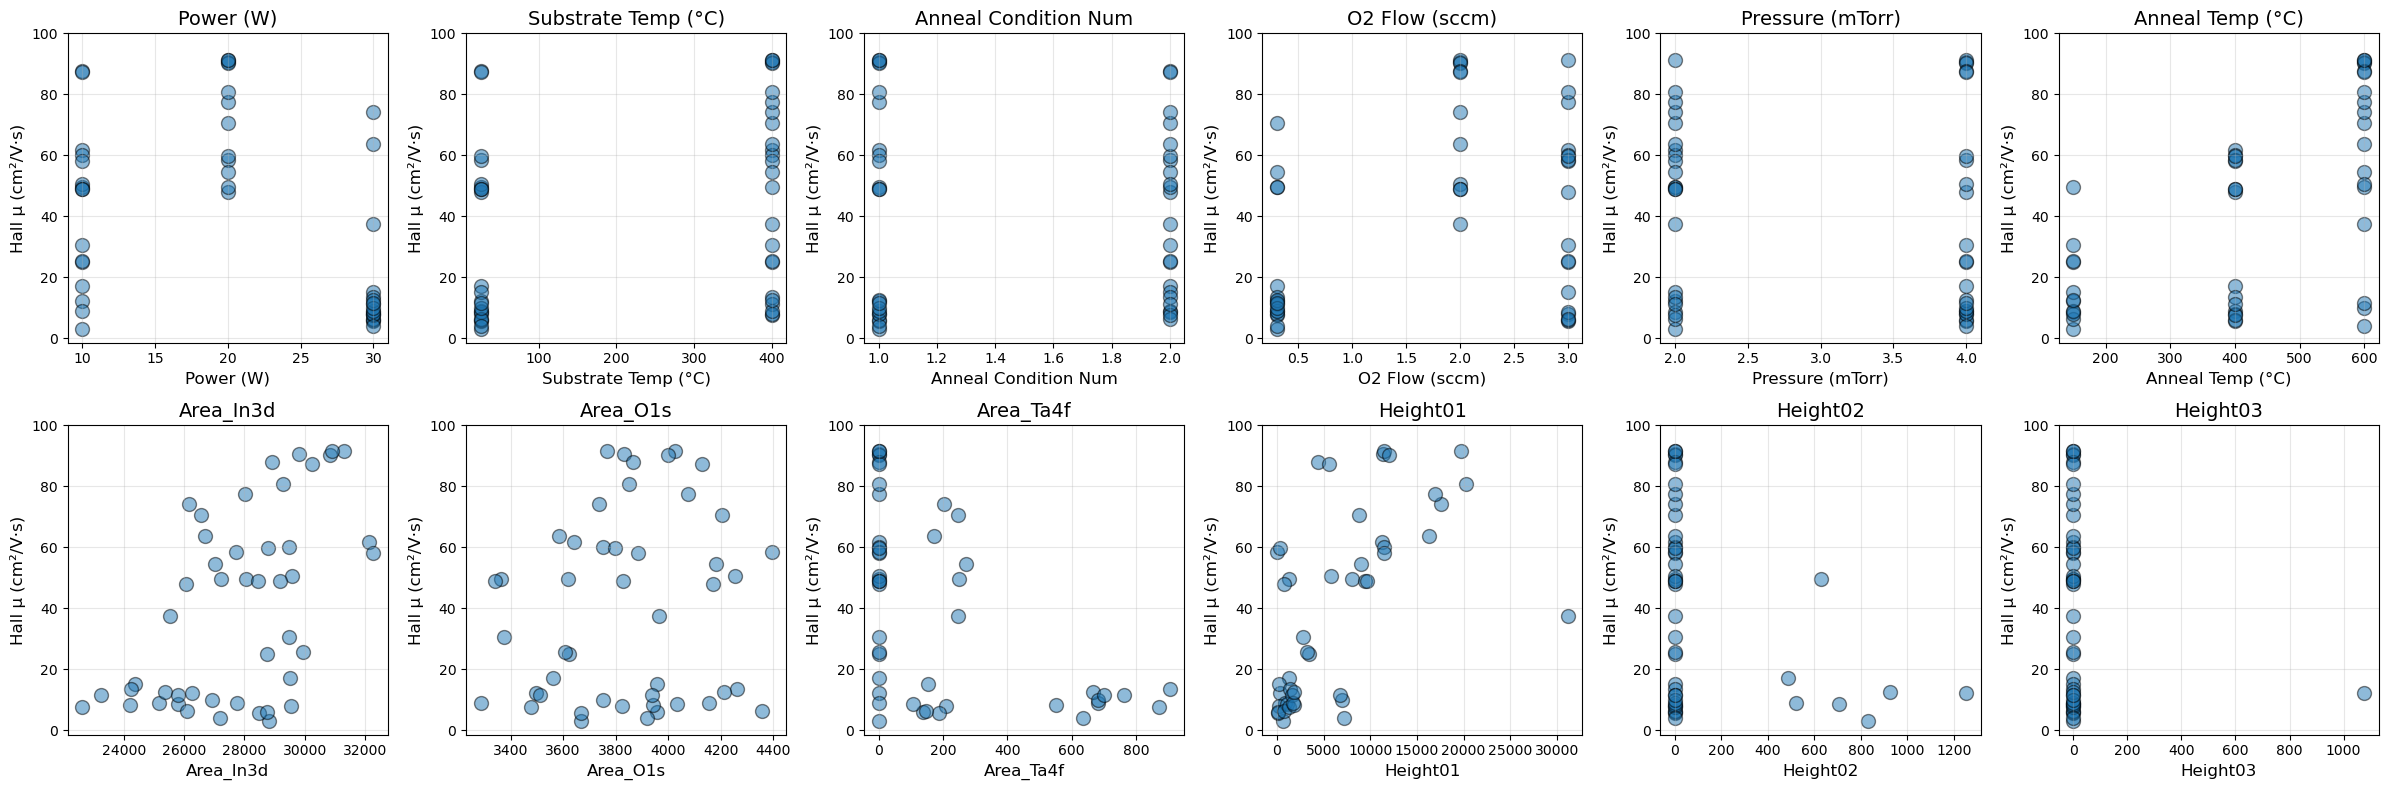

In [10]:
import numpy as np
import matplotlib.pyplot as plt

target_col = "Hall Mobility (cm^2/V·s)"

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "Anneal Condition",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]

# keep only predictors that exist and are numeric
predictors = [
    c for c in predictors
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

print("Predictors used:", predictors)

n_rows, n_cols = 2, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8))
axes = axes.flatten()

for ax, col in zip(axes, predictors):
    x = master_df[col].values
    y = master_df[target_col].values

    # scatter
    ax.scatter(x, y, s=100, alpha=0.5, edgecolor="k")

    # optional: simple linear fit line if enough points
    # if len(x[~np.isnan(x)]) > 2:
    #     try:
    #         coeffs = np.polyfit(x[~np.isnan(x)], y[~np.isnan(x)], 1)
    #         x_line = np.linspace(np.nanmin(x), np.nanmax(x), 50)
    #         y_line = coeffs[0] * x_line + coeffs[1]
    #         ax.plot(x_line, y_line, linewidth=2)
    #     except Exception:
    #         pass

    ax.set_title(col, fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Hall μ (cm²/V·s)", fontsize=12)
    ax.set_ylim(top=100)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(alpha=0.3)

# hide any unused axes (in case < 12 predictors)
for i in range(len(predictors), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


## Ridz Visualization

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


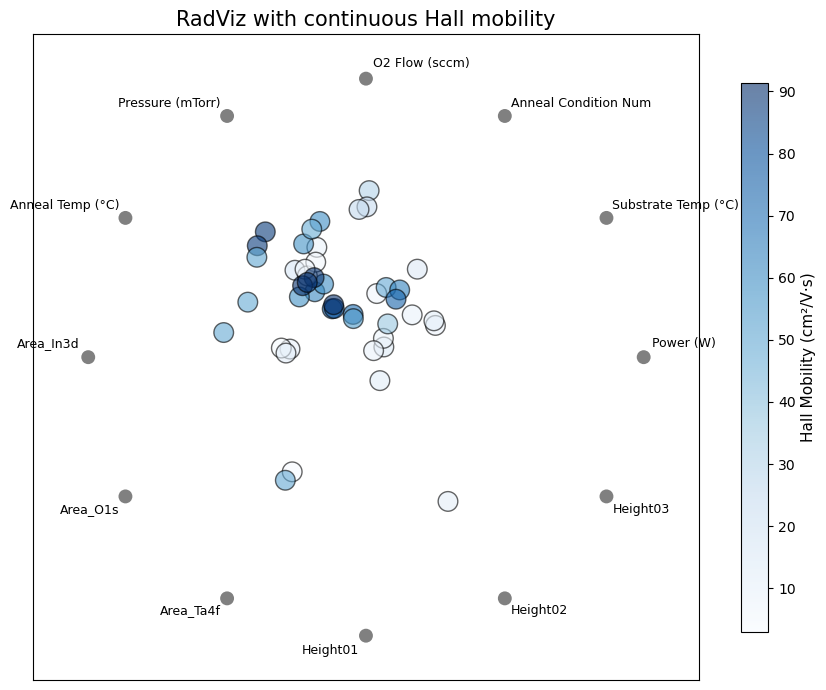

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import radviz

target_col = "Hall Mobility (cm^2/V·s)"

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]

predictors = [
    c for c in predictors
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

cols_for_radviz = predictors + [target_col]
df_radviz = master_df[cols_for_radviz].dropna().copy()

df_radviz["HallMobilityBin"] = pd.qcut(
    df_radviz[target_col],
    q=3,
    labels=["Low μ", "Med μ", "High μ"]
)

df_radviz_plot = df_radviz[predictors + ["HallMobilityBin"]].copy()

# jitter
np.random.seed(0)
jitter_strength = 0.02
for col in predictors:
    vals = df_radviz_plot[col].to_numpy(dtype=float)
    col_range = vals.max() - vals.min()
    if col_range == 0:
        continue
    noise = np.random.normal(0.0, jitter_strength * col_range, size=vals.shape)
    df_radviz_plot[col] = vals + noise

fig, ax = plt.subplots(figsize=(9, 7))

# 1) draw the radviz frame/anchors
radviz(df_radviz_plot, class_column="HallMobilityBin", ax=ax)

# 2) remove the legend
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# 3) fade/remove the class points that pandas drew
# ax.collections are the scatter groups from radviz
for coll in ax.collections:
    coll.set_alpha(0)      # or coll.set_visible(False)

ax.set_title("RadViz with continuous Hall mobility", fontsize=15)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

# pull labels in
for txt in ax.texts:
    x, y = txt.get_position()
    r = np.sqrt(x**2 + y**2)
    if r > 0:
        new_r = 1.03
        scale = new_r / r
        txt.set_position((x * scale, y * scale))
        txt.set_fontsize(9)

# ======================================================
# overlay your own scatter with colorbar
# ======================================================
X = df_radviz_plot[predictors].to_numpy(dtype=float)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1.0
X_norm = (X - X_min) / X_range

n_samples, n_features = X_norm.shape
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False)
anchors = np.stack([np.cos(angles), np.sin(angles)], axis=1)

den = X_norm.sum(axis=1)
den[den == 0] = 1e-12
coords = (X_norm @ anchors) / den[:, None]

x_rv = coords[:, 0]
y_rv = coords[:, 1]

hall_vals = df_radviz[target_col].to_numpy(dtype=float)

sc = ax.scatter(
    x_rv,
    y_rv,
    c=hall_vals,
    cmap="Blues",
    s=200,
    alpha=0.6,
    edgecolor="k",
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Hall Mobility (cm²/V·s)", fontsize=11)

plt.tight_layout()
plt.show()


# Linear Regression Model (preliminar)

## Model including all predictors (preliminar)

Formula used:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('Anneal Condition Num') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)')
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.721
Model:                                       OLS   Adj. R-squared:                  0.678
Method:                            Least Squares   F-statistic:                     16.82
Date:                           Wed, 15 Apr 2026   Prob (F-statistic):           1.81e-09
Time:                                   15:42:43   Log-Likelihood:                -192.57
No. Observations:                             46   AIC:                             399.1
Df Residuals:                                 39   BIC:                             411.9
Df Model:                                      6                                         
Cova

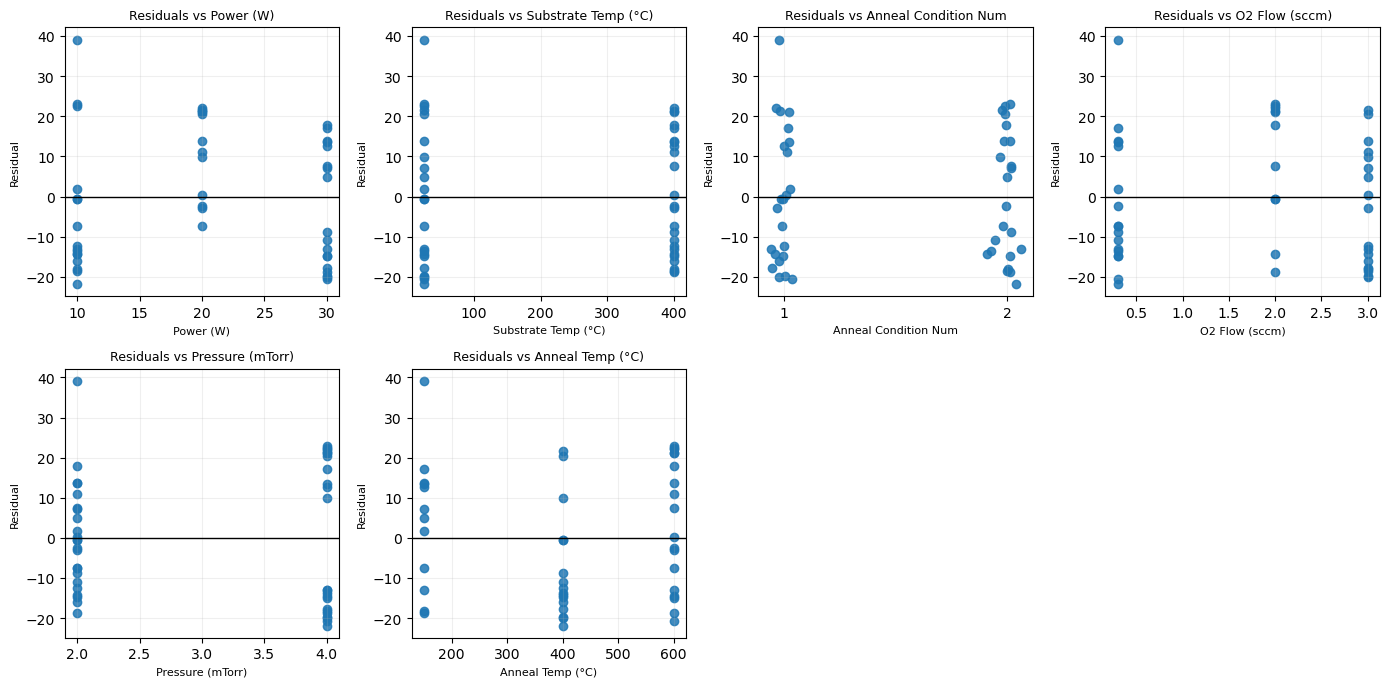

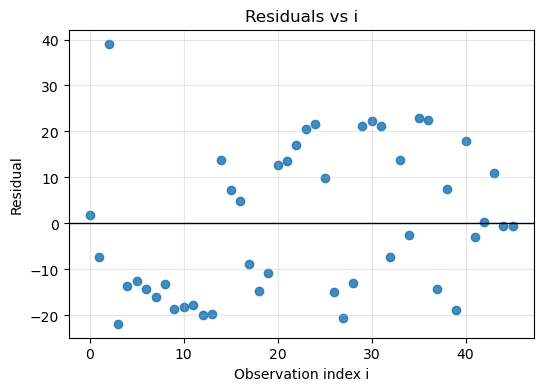

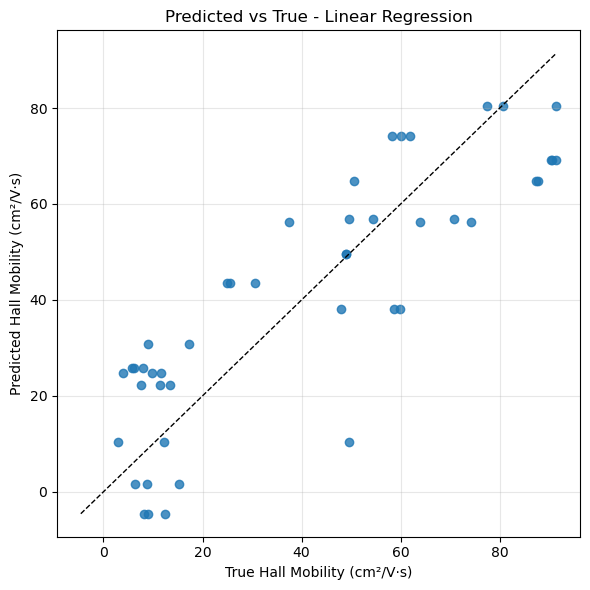

In [12]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# If you still have A, B, C, D, E, F from earlier Taguchi code, uncomment and run once:
# del A, B, C, D, E, F

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    #"Anneal Condition",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

# ----------------------------------
# Choose predictors to exclude
# ----------------------------------
# Put any names from `predictors` here to remove them from the model
exclude_for_model = {
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
    #"Anneal Condition Num",
}

# drop rows with missing data in any of these
df_use = master_df[predictors + [target]].dropna()

# ----------------------------------
# Build formula programmatically
# ----------------------------------
terms = []
for col in predictors:
    if col in exclude_for_model:
        continue

    if col == "Anneal Condition":
        # categorical
        terms.append("C(Q('Anneal Condition'))")
    else:
        terms.append(f"Q('{col}')")

rhs = " + ".join(terms)
formula = f"Q('{target}') ~ {rhs}"

print("Formula used:")
print(formula)

model = smf.ols(formula=formula, data=df_use).fit()
print(model.summary())

# =========================
# Residual plots per predictor
# =========================

resid = model.resid

# If you want residuals for all predictors (even excluded) use:
# pred_cols = predictors
# If you want residuals only for predictors included in the model, use:
pred_cols = [col for col in predictors if col not in exclude_for_model]

n = len(pred_cols)
n_rows = 3
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        # jitter for categorical
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

# hide unused axes if any
for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# Residuals vs index (like the slide)
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i")
plt.grid(alpha=0.3)
plt.show()

summary = model.summary2()

# Extract main tables
coef_table = summary.tables[1]    # coefficients table
info_table = summary.tables[0]    # model info (R^2, etc.)

# Save them into Excel (different sheets)
with pd.ExcelWriter("output/ols_model_summary.xlsx") as writer:
    info_table.to_excel(writer, sheet_name="Model_Info")
    coef_table.to_excel(writer, sheet_name="Coefficients")


################################
# Get true and predicted
################################

y_true = df_use[target].values               # true Hall Mobility
y_pred = model.fittedvalues.values           # or model.predict(df_use)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.8)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)
plt.xlabel("True Hall Mobility (cm²/V·s)")
plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
plt.title("Predicted vs True - Linear Regression")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [13]:
# print(model.params.index)
# print(sorted(df_use["Anneal Condition Num"].unique()))


In [14]:
from statsmodels.stats.anova import anova_lm

# =========================
# ANOVA table (Type II) + clean names
# =========================

def clean_term_name(term: str) -> str:
    """
    Remove patsy's Q(...) and C(Q(...)) wrappers,
    keeping the original variable name (with units).
    """
    # e.g. "Q('Power (W)')" -> "Power (W)"
    if term.startswith("Q('") and term.endswith("')"):
        return term[3:-2]

    # e.g. "C(Q('Anneal Condition Num'))" -> "Anneal Condition Num"
    if term.startswith("C(Q('") and term.endswith("'))"):
        return term[5:-3]

    # leave anything else as is (e.g. "Residual")
    return term

anova_table = anova_lm(model, typ=2)

# apply cleaning to the index (row names)
anova_table.index = [clean_term_name(t) for t in anova_table.index]

print("\n=== ANOVA table (Type II, cleaned names) ===")
print(anova_table)
anova_table.to_excel("output/anova_test.xlsx")



=== ANOVA table (Type II, cleaned names) ===
                            sum_sq    df          F        PR(>F)
Power (W)              6666.774275   1.0  22.308242  2.987830e-05
Substrate Temp (°C)    2903.584421   1.0   9.715923  3.423321e-03
Anneal Condition Num     41.772205   1.0   0.139777  7.105273e-01
O2 Flow (sccm)         4027.687936   1.0  13.477378  7.218141e-04
Pressure (mTorr)        110.170680   1.0   0.368651  5.472594e-01
Anneal Temp (°C)      14848.417817   1.0  49.685513  1.836964e-08
Residual              11655.073389  39.0        NaN           NaN


## manually selected model with only significant factors

Formula used:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)') + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):C(Q('Anneal Condition Num'))
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.755
Model:                                       OLS   Adj. R-squared:                  0.702
Method:                            Least Squares   F-statistic:                     14.23
Date:                           Wed, 15 Apr 2026   Prob (F-statistic):           3.33e-09
Time:                                   15:42:44   Log-Likelihood:                -189.63
No. Observations:                             46   AIC:                             397.3
Df Residuals:                                 37   BIC:                           

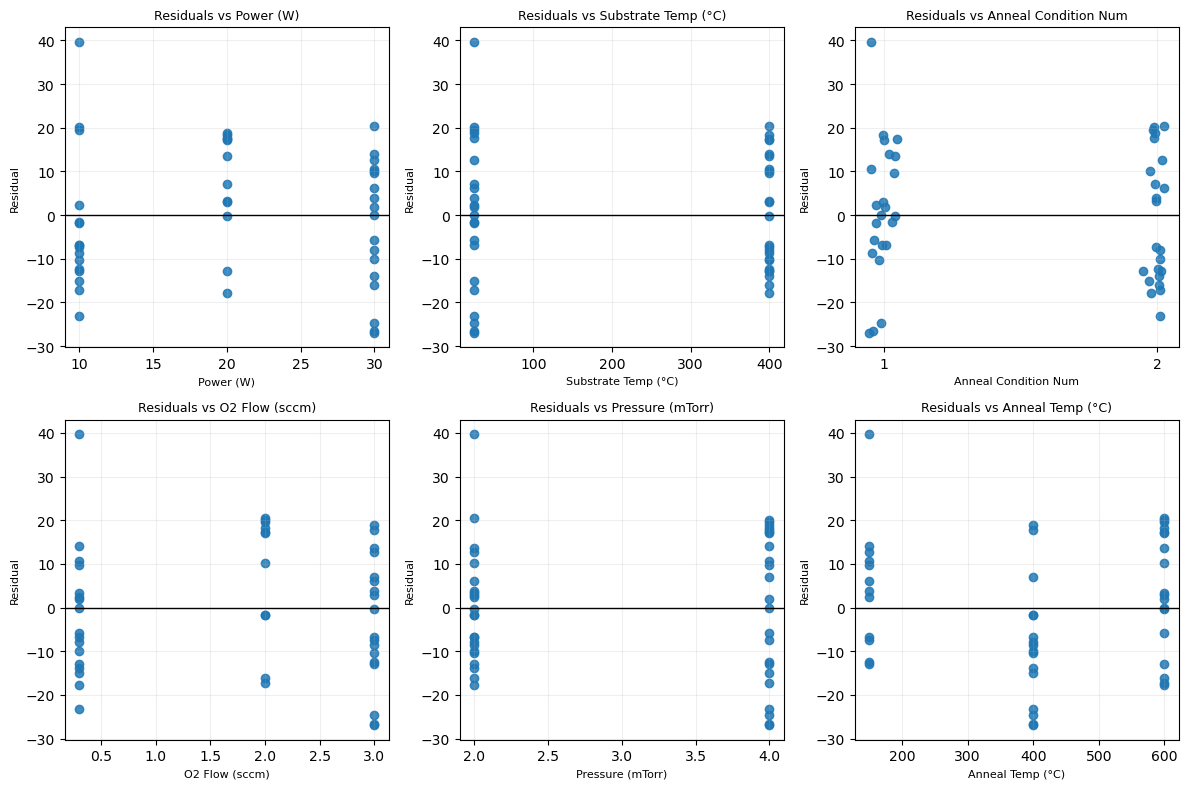

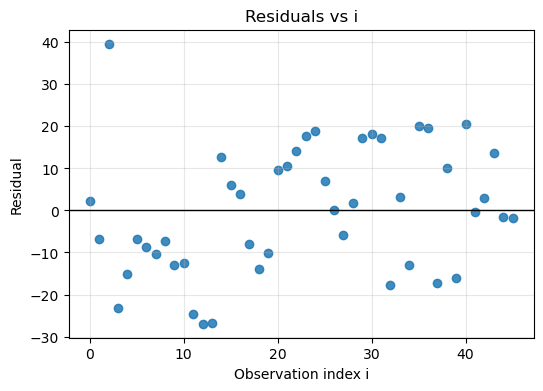

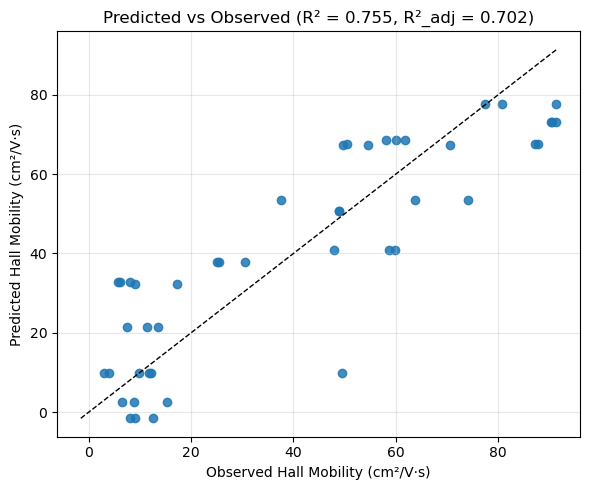

In [15]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
#del A, B, C, D, E, F    

target = "Hall Mobility (cm^2/V·s)"

# ----------------------------------
# Process predictors used in ANOVA
# ----------------------------------
process_predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]

# Data subset: only these columns for now
df_use = master_df[process_predictors + [target]].dropna()

# ----------------------------------
# Build formula with:
#   - all main effects
#   - only selected interaction terms
# ----------------------------------

# main effects
main_terms = [
    "Q('Power (W)')",
    "Q('Substrate Temp (°C)')",
    "Q('O2 Flow (sccm)')",
    "Q('Pressure (mTorr)')",
    "Q('Anneal Temp (°C)')",
    #"C(Q('Anneal Condition Num'))",   # categorical
]

# interaction terms you highlighted in the ANOVA
interaction_terms = [
    # Substrate Temp × O2 Flow
    "Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)')",

    # Power × O2 Flow
    "Q('Power (W)'):Q('O2 Flow (sccm)')",

    # Power × Anneal Condition Num (categorical)
    "Q('Power (W)'):C(Q('Anneal Condition Num'))",
]


rhs = " + ".join(main_terms + interaction_terms)
formula = f"Q('{target}') ~ {rhs}"

print("Formula used:")
print(formula)

model = smf.ols(formula=formula, data=df_use).fit()
print(model.summary())

# =========================
# Residual plots per predictor (main effects only)
# =========================
resid = model.resid
pred_cols = process_predictors  # only the six process factors

n = len(pred_cols)
n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        # jitter for categorical
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

# hide unused axes if any
for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# Residuals vs index
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Predicted vs observed plot
# =========================
y_true = df_use[target]
y_pred = model.fittedvalues

plt.figure(figsize=(6, 5))
plt.scatter(y_true, y_pred, alpha=0.85)
plt.xlabel("Observed Hall Mobility (cm²/V·s)")
plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
plt.title("Predicted vs Observed")
r2 = model.rsquared
r2_adj = model.rsquared_adj
plt.title(f"Predicted vs Observed (R² = {r2:.3f}, R²_adj = {r2_adj:.3f})")

# 45-degree reference line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# Interaction terms and anova

In here I am including the main effects (6) and the interaction terms giving a total of 21 coefficients

In [16]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]
target = "Hall Mobility (cm^2/V·s)"

df_use = master_df[predictors + [target]].dropna()

# -------------------------
# Build formula with ALL 2-way interactions
# -------------------------
rhs = (
    "Q('Power (W)')"
    " + Q('Substrate Temp (°C)')"
    " + C(Q('Anneal Condition Num'))"
    " + Q('O2 Flow (sccm)')"
    " + Q('Pressure (mTorr)')"
    " + Q('Anneal Temp (°C)')"
)

# ** 2 means: include all main effects and all 2-way interactions
formula = f"Q('Hall Mobility (cm^2/V·s)') ~ ({rhs}) ** 2"
print("Formula:", formula)

# -------------------------
# Fit model
# -------------------------
model = smf.ols(formula=formula, data=df_use).fit()
print(model.summary())

# -------------------------
# ANOVA (Type II) with cleaned names
# -------------------------
def _clean_single(term: str) -> str:
    term = term.strip()
    if term.startswith("Q('") and term.endswith("')"):
        return term[3:-2]      # drop Q('  ')
    if term.startswith("C(Q('") and term.endswith("'))"):
        return term[5:-3]      # drop C(Q('  '))
    return term

def clean_term_name(term: str) -> str:
    # Handle interactions like "Q('Power (W)'):Q('Substrate Temp (°C)')"
    if ":" in term:
        parts = term.split(":")
        clean_parts = [_clean_single(p) for p in parts]
        return " × ".join(clean_parts)  # nicer symbol for interaction
    else:
        return _clean_single(term)

anova_table = anova_lm(model, typ=2)
anova_table.index = [clean_term_name(t) for t in anova_table.index]

print("\n=== ANOVA table (Type II, with all 2-way interactions, cleaned names) ===")
print(anova_table)

# If you want to export:
anova_table.to_excel("output/anova_all_2way_interactions.xlsx")


Formula: Q('Hall Mobility (cm^2/V·s)') ~ (Q('Power (W)') + Q('Substrate Temp (°C)') + C(Q('Anneal Condition Num')) + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)')) ** 2
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.918
Model:                                       OLS   Adj. R-squared:                  0.877
Method:                            Least Squares   F-statistic:                     22.31
Date:                           Wed, 15 Apr 2026   Prob (F-statistic):           3.09e-12
Time:                                   15:42:45   Log-Likelihood:                -164.50
No. Observations:                             46   AIC:                             361.0
Df Residuals:                                 30   BIC:                             390.3
Df Model:                                     15                                         

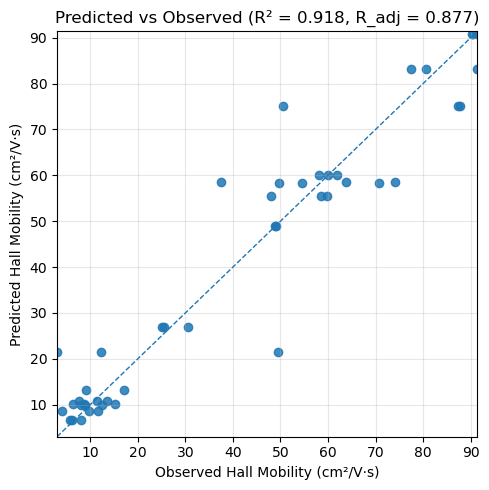

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pred_vs_observed(model, df, target_col, title_prefix="Predicted vs Observed"):
    """
    Scatter plot of predicted vs observed values for a fitted statsmodels OLS model.

    Parameters
    ----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Fitted OLS model (result of smf.ols(...).fit()).
    df : pandas.DataFrame
        Data used for prediction (can be training data or new data).
    target_col : str
        Name of the column in df that contains the true response values.
    title_prefix : str, optional
        Text to put at the beginning of the plot title.
    """
    # True values and predictions
    y_true = df[target_col]
    y_pred = model.predict(df)

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.85)

    # 45-degree reference line
    lims = [
        np.nanmin([y_true.min(), y_pred.min()]),
        np.nanmax([y_true.max(), y_pred.max()])
    ]
    plt.plot(lims, lims, linestyle="--", linewidth=1)
    plt.xlim(lims)
    plt.ylim(lims)

    # Handle R^2 if available (for new-data predictions it is still the training R^2)
    try:
        r2 = model.rsquared
        r2_adj = model.rsquared_adj
        title = f"{title_prefix} (R² = {r2:.3f}, R_adj = {r2_adj:.3f})"
    except AttributeError:
        title = title_prefix

    plt.xlabel("Observed Hall Mobility (cm²/V·s)")
    plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_pred_vs_observed(model, df_use, target_col=target)

## Calculating cooks distance for outlier point

In [18]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import OLSInfluence

infl = OLSInfluence(model)

h = infl.hat_matrix_diag                    # leverage h_ii
r_std = infl.resid_studentized_internal     # standardized residuals r_i
r_ = infl.resid
p_eff = int(model.df_model) + 1             # effective #params incl. intercept

# manual Cook's D using standardized residuals
cooks_manual = (r_std**2 * h) / (p_eff * (1.0 - h))

# statsmodels Cook's D for comparison
cooks_sm, _ = infl.cooks_distance

X = model.model.exog
resid = model.resid
h = infl.hat_matrix_diag

n = len(resid)
p_eff = int(model.df_model) + 1          # same as above
df_resid = model.df_resid               # effective residual df
MSE = np.sum(resid**2) / df_resid       # > 0

cooks_manual2 = (resid**2 / (p_eff * MSE)) * (h / (1.0 - h)**2)


compare = pd.DataFrame({
    "cooks_manual": cooks_manual,
    "cooks_statsmodels": cooks_sm,
})
print(compare)


    cooks_manual  cooks_statsmodels
0   3.592542e-02       2.612758e-02
1   1.407530e-01       1.023658e-01
2   3.188981e-01       2.319259e-01
3   1.819561e-02       1.323317e-02
5   1.819561e-02       1.323317e-02
6   1.324826e-03       9.635097e-04
7   1.417088e-27       1.030609e-27
8   1.324826e-03       9.635097e-04
9   5.008987e-03       3.642899e-03
10  1.635587e-03       1.189518e-03
11  9.200180e-04       6.691040e-04
12  8.052588e-04       5.856427e-04
13  2.931154e-04       2.131749e-04
14  1.267081e-04       9.215131e-05
15  1.077489e-02       7.836281e-03
16  8.090888e-04       5.884282e-04
17  5.678778e-03       4.130020e-03
18  2.951490e-03       2.146538e-03
19  4.381212e-03       3.186336e-03
20  1.407332e-04       1.023514e-04
21  1.247481e-03       9.072587e-04
22  3.142554e-04       2.285494e-04
23  2.813978e-03       2.046530e-03
24  4.014459e-03       2.919606e-03
25  7.678175e-03       5.584127e-03
26  2.279645e-02       1.657924e-02
27  7.017079e-04       5.103

4/n cutoff for Cook's distance: 0.0870

Points with Cook's D > 4/n:
    idx  leverage  std_resid   cooks_d
1     1  0.333333  -2.122286  0.102366
2     2  0.333333   3.194486  0.231926
38   37  0.333333  -2.825393  0.181428
43   39  0.333333  -2.398343  0.130728


/tmp/ipykernel_3763595/3475557036.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for region, grp in diag.groupby("region"):


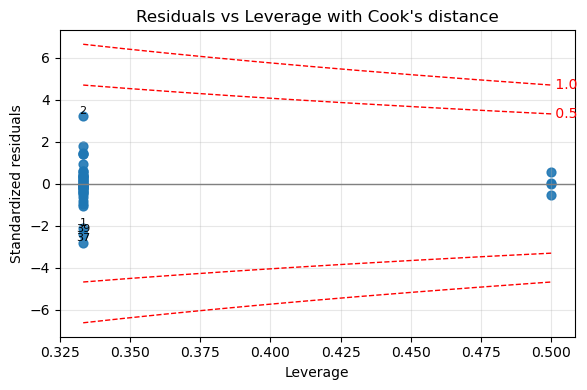

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import OLSInfluence

# ---------------------------------
# 1) Influence measures
# ---------------------------------
infl = OLSInfluence(model)
leverage  = infl.hat_matrix_diag
std_resid = infl.resid_studentized_internal
cooks_d, _ = infl.cooks_distance

# k used in Cook's D formula inside statsmodels
k = model.model.exog.shape[1]

# sample size
n = len(df_use)
cutoff_4_over_n = 4 / n
print(f"4/n cutoff for Cook's distance: {cutoff_4_over_n:.4f}")

# ---------------------------------
# 2) Build diagnostics table
# ---------------------------------
diag = pd.DataFrame({
    "idx": np.arange(len(df_use)),
    "leverage": leverage,
    "std_resid": std_resid,
    "cooks_d": cooks_d,
})

# classify by Cook's D
diag["region"] = pd.cut(
    diag["cooks_d"],
    bins=[-np.inf, 0.5, 1.0, np.inf],
    labels=["D < 0.5", "0.5 <= D < 1.0", "D >= 1.0"],
)

# flag observations above 4/n
diag["above_4_over_n"] = diag["cooks_d"] > cutoff_4_over_n

print("\nPoints with Cook's D > 4/n:")
print(diag.loc[diag["above_4_over_n"], ["idx", "leverage", "std_resid", "cooks_d"]])

# ---------------------------------
# 3) Plot: Residuals vs Leverage with Cook's contours
# ---------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

color_map = {
    "D < 0.5": "tab:blue",
    "0.5 <= D < 1.0": "tab:orange",
    "D >= 1.0": "tab:red",
}

for region, grp in diag.groupby("region"):
    ax.scatter(
        grp["leverage"],
        grp["std_resid"],
        label=region,
        alpha=0.9,
        s=40,
        color=color_map[region],
    )

# optionally label the 4/n points on the plot
for _, row in diag[diag["above_4_over_n"]].iterrows():
    ax.text(row["leverage"], row["std_resid"], str(int(row["idx"])),
            fontsize=8, ha="center", va="bottom")

ax.set_xlabel("Leverage")
ax.set_ylabel("Standardized residuals")
ax.set_title("Residuals vs Leverage with Cook's distance")

# Cook's distance contours that match statsmodels
lev_grid = np.linspace(leverage.min(), leverage.max(), 200)
lev_grid = lev_grid[(lev_grid > 0) & (lev_grid < 1)]

for d in [0.5, 1.0]:
    r_grid = np.sqrt(d * k * (1 - lev_grid) / lev_grid)
    ax.plot(lev_grid,  r_grid, "r--", linewidth=1)
    ax.plot(lev_grid, -r_grid, "r--", linewidth=1)
    ax.text(lev_grid[-1], r_grid[-1], f" {d}", color="r", va="center")

ax.axhline(0, color="grey", lw=1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Coefficient of variation without this point

Rows dropped: 1


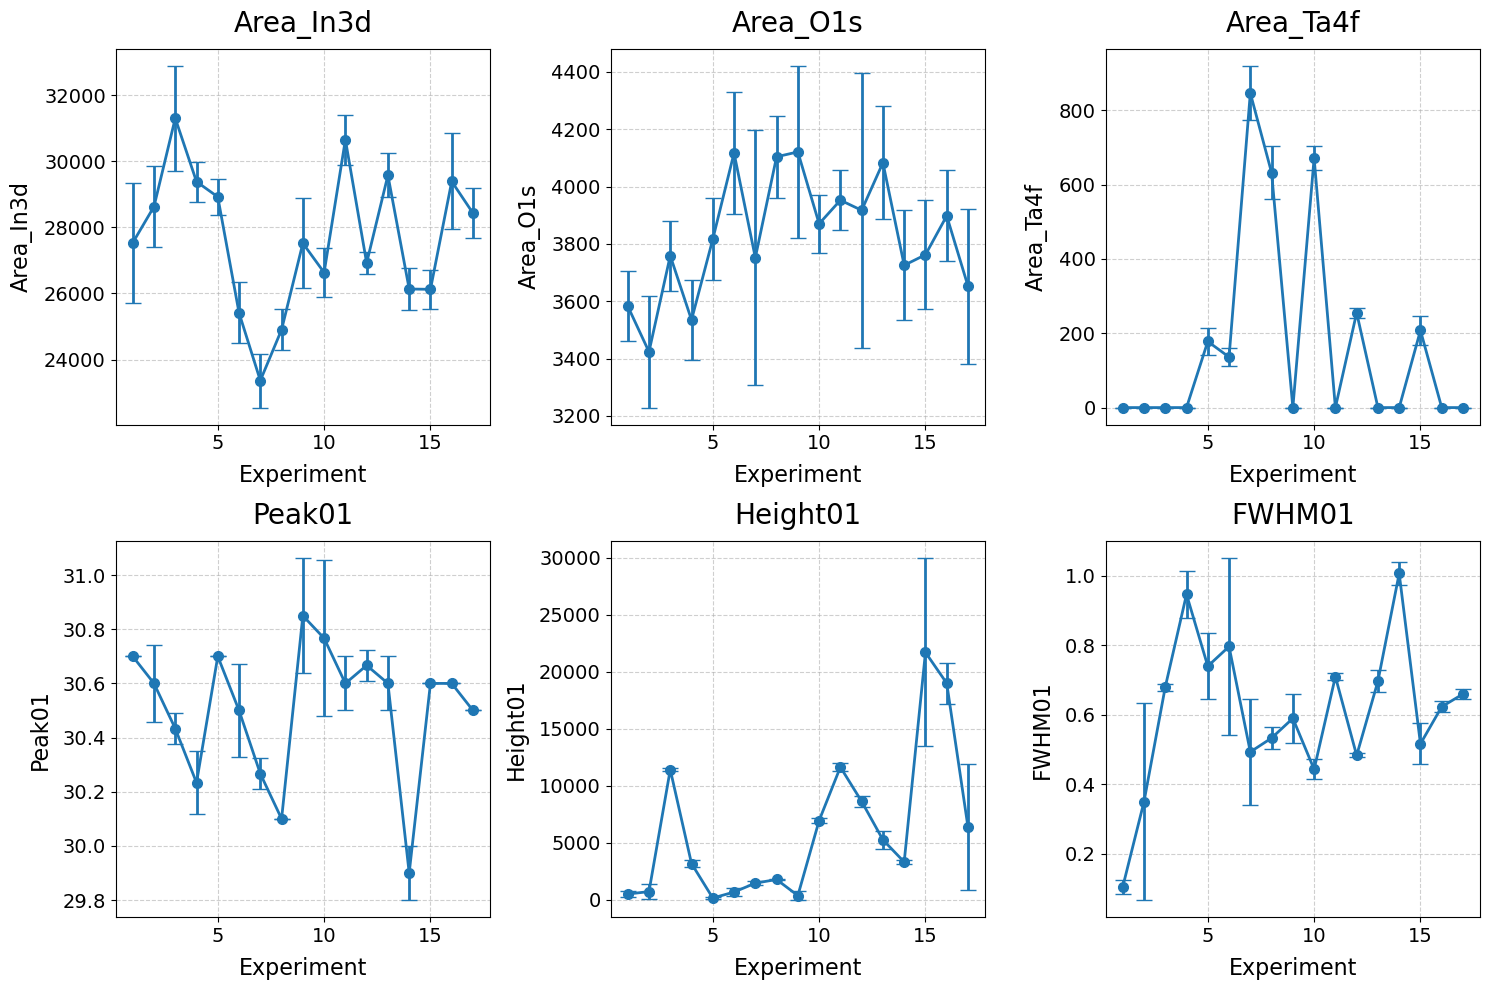

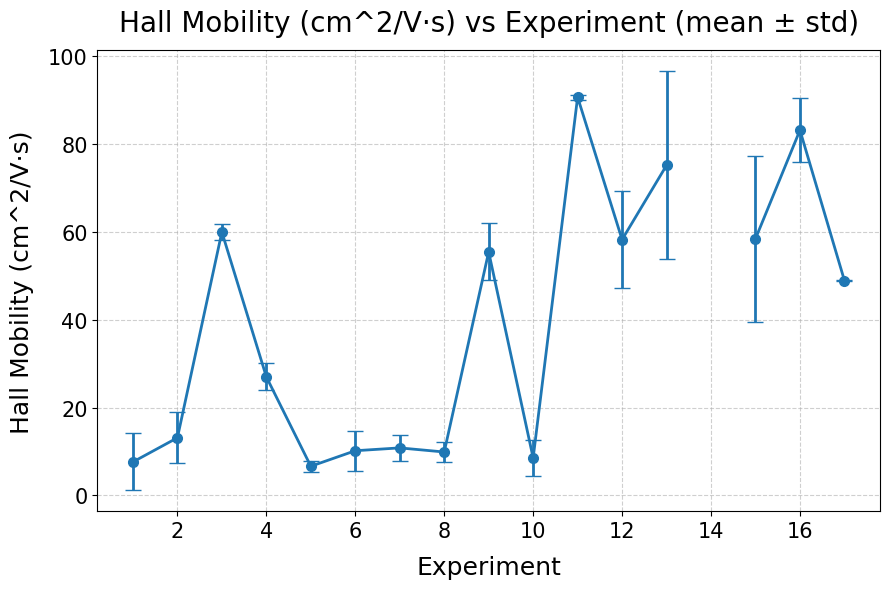

Coefficient of variation per experiment (percent):


,CV_%_Area_In3d,CV_%_Area_O1s,CV_%_Area_Ta4f,CV_%_Peak01,CV_%_Height01,CV_%_FWHM01,CV_%_Hall Mobility (cm^2/V·s)
Experiment,,,,,,,
1,6.605,3.394,nan,0.000,50.200,20.203,85.299
2,4.295,5.680,nan,0.462,92.257,80.812,44.049
3,5.074,3.237,nan,0.190,1.339,1.471,3.000
4,2.043,3.940,nan,0.382,9.652,7.190,11.264
5,1.916,3.764,20.419,0.000,34.032,12.891,18.470
6,3.639,5.132,17.890,0.568,56.718,31.862,45.191
7,3.497,11.835,8.691,0.191,11.845,30.764,27.956
8,2.481,3.469,11.211,0.000,4.629,5.728,23.420
9,4.953,7.291,nan,0.688,105.509,11.985,11.708


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Drop the specific row (Experiment 1, replicate with 49.5 mobility, O2, 10 W, 25 °C, etc.)
mask_outlier = (
    (master_df["Experiment"] == 1) &
    (master_df["Power (W)"] == 10) &
    (master_df["Substrate Temp (°C)"] == 25) &
    (master_df["O2 Flow (sccm)"] == 0.3) &
    (master_df["Pressure (mTorr)"] == 2) &
    (master_df["Anneal Temp (°C)"] == 150) &
    (master_df["Hall Mobility (cm^2/V·s)"] == 49.5)
)

print("Rows dropped:", mask_outlier.sum())

df_clean = master_df.loc[~mask_outlier].copy()

# 1) columns we want to analyze
cols_to_agg = [
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Peak01",
    "Height01",
    "FWHM01",
    "Hall Mobility (cm^2/V·s)",
]

# keep only those that exist
cols_to_agg = [c for c in cols_to_agg if c in df_clean.columns]

# 2) group by experiment and compute mean and std
grp_mean = df_clean.groupby("Experiment")[cols_to_agg].mean(numeric_only=True)
grp_std  = df_clean.groupby("Experiment")[cols_to_agg].std(numeric_only=True)

# separate hall mobility if present
hall_col = "Hall Mobility (cm^2/V·s)"
has_hall = hall_col in cols_to_agg

# variables to plot in the 3x2 grid (exclude hall mobility)
grid_cols = [c for c in cols_to_agg if c != hall_col]

# 3) make a 2x3 figure for XPS features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, grid_cols):
    x = grp_mean.index.values
    y = grp_mean[col].values
    yerr = grp_std[col].values

    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    ax.set_title(col, fontsize=20, pad=12)
    ax.set_xlabel("Experiment", fontsize=16, labelpad=8)
    ax.set_ylabel(col, fontsize=16, labelpad=8)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.grid(True, linestyle="--", alpha=0.6)

# hide any unused axes
for i in range(len(grid_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# 3b) plot hall mobility separately
if has_hall:
    plt.figure(figsize=(9, 6))
    x = grp_mean.index.values
    y = grp_mean[hall_col].values
    yerr = grp_std[hall_col].values

    plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    plt.title(f"{hall_col} vs Experiment (mean ± std)", fontsize=20, pad=14)
    plt.xlabel("Experiment", fontsize=18, labelpad=10)
    plt.ylabel(hall_col, fontsize=18, labelpad=10)
    plt.tick_params(axis="both", which="major", labelsize=15)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 4) coefficient of variation (CV = std / mean) as percent
cv_df = (grp_std / grp_mean.replace(0, np.nan)) * 100
cv_df = cv_df.add_prefix("CV_%_")

print("Coefficient of variation per experiment (percent):")
display(cv_df.style.format("{:.3f}").background_gradient(cmap="Blues"))

cv_df.to_excel("output/cv_percetage_no_outlier.xlsx", index_label=False)


## Re-fitting the model without the detected cooks distance outlier 

High Cook's distance points:
    Power (W)  Substrate Temp (°C)  Anneal Condition Num  O2 Flow (sccm)  \
1          10                   25                     1             0.3   
2          10                   25                     1             0.3   
38         10                   25                     2             2.0   
43         30                  400                     2             2.0   

    Pressure (mTorr)  Anneal Temp (°C)  Hall Mobility (cm^2/V·s)   cooks_d  
1                  2               150                      3.02  0.102366  
2                  2               150                     49.50  0.231926  
38                 4               600                     50.50  0.181428  
43                 2               600                     37.50  0.130728  
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.984
Model:                   

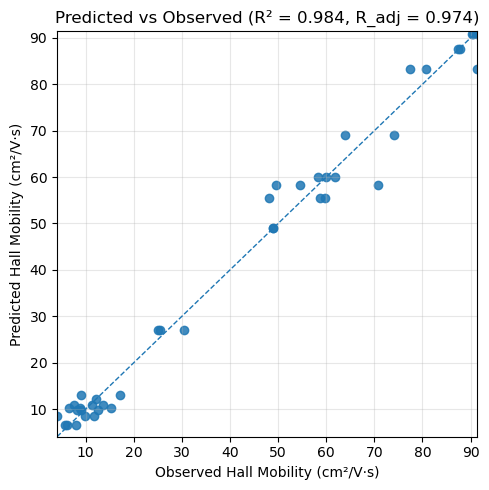

In [21]:
from statsmodels.stats.outliers_influence import OLSInfluence

# -------------------------
# 1) Get Cook's distance
# -------------------------
influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]   # array of D_i

# Put Cook's D back on the data frame (same index order)
df_cd = df_use.copy()
df_cd["cooks_d"] = cooks_d

# Rule-of-thumb cutoff (you can also use 4/(n - k - 1), here 4/n is fine)
n = df_cd.shape[0]
cutoff = 4 / n

high_cd = df_cd["cooks_d"] > cutoff
print("High Cook's distance points:")
print(df_cd.loc[high_cd])

# -------------------------
# 2) Drop the high-D point(s) and refit
# -------------------------
df_refit = df_cd.loc[~high_cd].drop(columns="cooks_d")

model_refit = smf.ols(formula=formula, data=df_refit).fit()
print(model_refit.summary())

anova_refit = anova_lm(model_refit, typ=2)
anova_refit.index = [clean_term_name(t) for t in anova_refit.index]
print("\n=== ANOVA after removing high Cook's distance point(s) ===")
anova_refit.to_excel("output/anova_no_high_cooksd.xlsx")
print(anova_refit)
plot_pred_vs_observed(model_refit, df_refit, target_col=target)



### not significant predictors to consider removing:

In [22]:
# =========================
# Non-significant predictors (by ANOVA, after refit)
# =========================

alpha = 0.05  # significance level; change if you want (e.g. 0.10)

# anova_refit already computed in the previous cell
# Drop the Residual row and keep terms with p-value > alpha
nonsig_terms = (
    anova_refit
    .drop(index=["Residual"], errors="ignore")
    .loc[anova_refit["PR(>F)"] > alpha]
)

print(f"Non-significant terms at alpha = {alpha}:")
if nonsig_terms.empty:
    print("  None – all terms are significant at this level.")
else:
    print(nonsig_terms[["df", "F", "PR(>F)"]])


Non-significant terms at alpha = 0.05:
                                          df         F    PR(>F)
Power (W) × Anneal Condition Num         1.0  0.032132  0.859127
Anneal Condition Num × O2 Flow (sccm)    1.0  0.019224  0.890794
Pressure (mTorr)                         1.0  2.664624  0.114656
Anneal Condition Num × Pressure (mTorr)  1.0  0.942289  0.340634
Power (W) × Anneal Temp (°C)             1.0  3.258345  0.082655
Substrate Temp (°C) × O2 Flow (sccm)     1.0  4.065157  0.054218
Substrate Temp (°C) × Anneal Temp (°C)   1.0  0.296686  0.590609
O2 Flow (sccm) × Pressure (mTorr)        1.0  0.417481  0.523859


## Residuals vs predicted plot

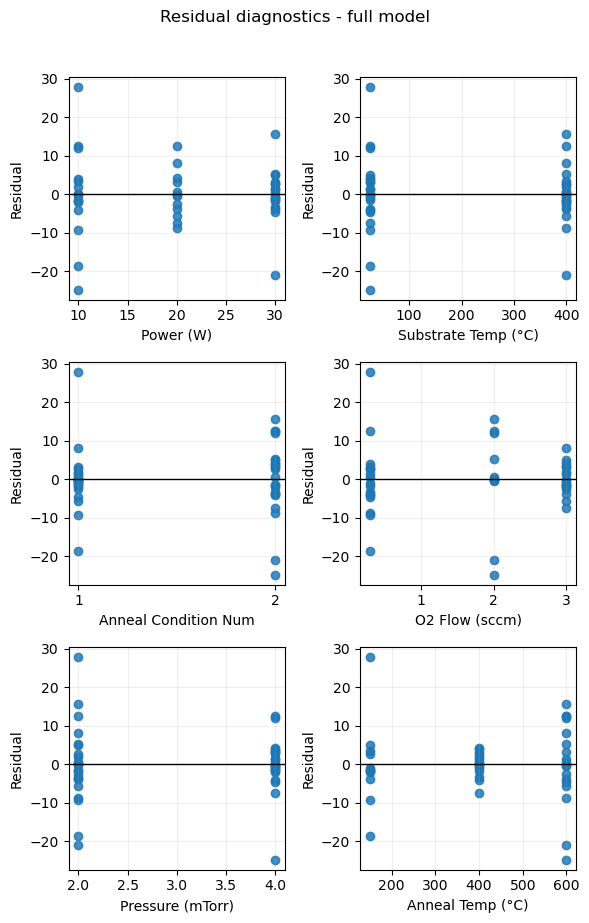

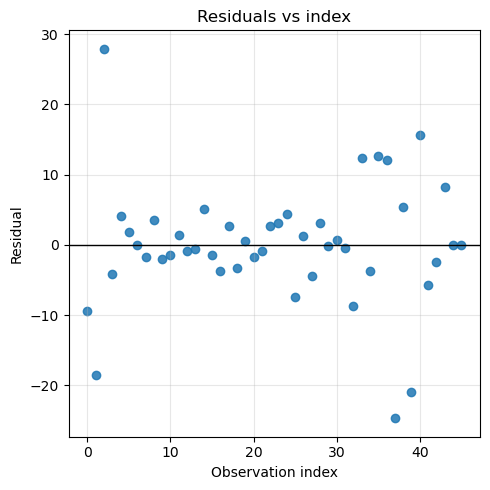

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_residuals_vs_predictors(
    model,
    df,
    predictors,
    categorical_cols=None,
    jitter_std=0.0,
    include_index_plot=True,
    title_prefix="Residuals vs predictors"
):
    """
    Make residuals vs predictor plots for a fitted statsmodels OLS model.

    Parameters
    ----------
    model : statsmodels RegressionResultsWrapper
        Fitted OLS model (from smf.ols(...).fit()).
    df : pandas.DataFrame
        Data frame used for the residual plots (same structure as used to fit).
    predictors : list of str
        Column names in df to use as predictors on the x-axes.
    categorical_cols : list of str or None
        Columns that should be treated as categorical and jittered on x.
        Example: ["Anneal Condition Num"].
    jitter_std : float
        Standard deviation of normal noise added to categorical x for jitter.
    include_index_plot : bool
        If True, also plot residuals vs observation index.
    title_prefix : str
        Optional prefix for a super-title (not required).
    """
    if categorical_cols is None:
        categorical_cols = []

    # Residuals from the model (on this data)
    resid = model.resid

    # Layout for subplots
    n = len(predictors)
    n_cols = 2
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 3 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, predictors):
        x = df[col].values
        y = resid.values

        if col in categorical_cols:
            # jitter categorical levels on x-axis
            x_plot = x.astype(float) + np.random.normal(0, jitter_std, size=len(x))
            ax.scatter(x_plot, y, alpha=0.85)
            ax.set_xticks(sorted(np.unique(x)))
        else:
            ax.scatter(x, y, alpha=0.85)

        ax.axhline(0, color="k", linewidth=1)
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel("Residual", fontsize=10)
        ax.grid(alpha=0.2)

    # Hide any unused axes
    for i in range(len(predictors), len(axes)):
        axes[i].set_visible(False)

    if title_prefix:
        fig.suptitle(title_prefix, fontsize=12, y=1.02)

    plt.tight_layout()
    plt.show()

    # Optional residuals vs index plot
    if include_index_plot:
        plt.figure(figsize=(5, 5))
        plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
        plt.axhline(0, color="k", linewidth=1)
        plt.xlabel("Observation index")
        plt.ylabel("Residual")
        plt.title("Residuals vs index")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_residuals_vs_predictors(
    model=model,
    df=df_use,
    predictors=predictors,  # your existing list
    categorical_cols=["Anneal Condition Num"],
    title_prefix="Residual diagnostics - full model"
)



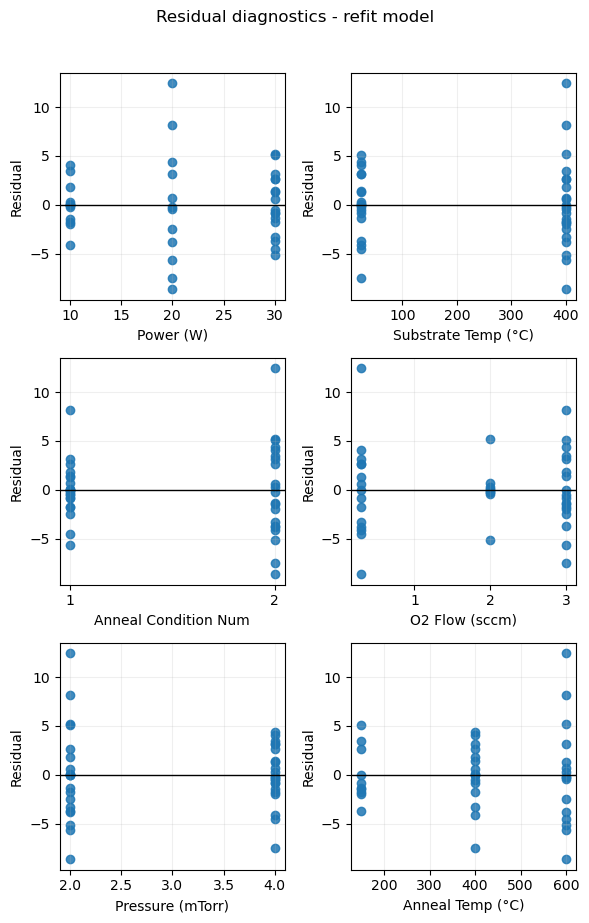

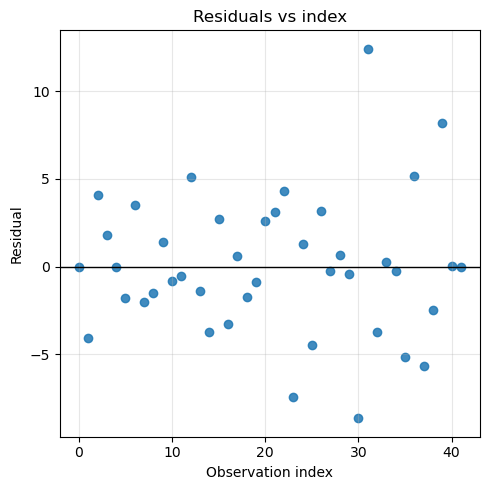

In [24]:
plot_residuals_vs_predictors(
    model=model_refit,
    df=df_refit,
    predictors=predictors,
    categorical_cols=["Anneal Condition Num"],
    title_prefix="Residual diagnostics - refit model"
)


## Threshold based on p-value pval_threshold = 0.10

In [25]:
# Get Type II ANOVA table
anova_table = anova_lm(model, typ=2)
anova_table.index = [clean_term_name(t) for t in anova_table.index]

alpha = 0.10  # p-value threshold

terms_to_keep = []
terms_not_sig = []

for term in anova_table.index:
    if term == "Residual":
        continue

    pval = anova_table.loc[term, "PR(>F)"]

    if pval < alpha:
        terms_to_keep.append(term)
    else:
        terms_not_sig.append(term)

print(f"Using alpha = {alpha}")
print("\nStatistically significant terms (p < alpha):")
for t in terms_to_keep:
    print(f"  - {t} (p = {anova_table.loc[t, 'PR(>F)']:.4f})")

print("\nNot statistically significant terms (p ≥ alpha):")
for t in terms_not_sig:
    print(f"  - {t} (p = {anova_table.loc[t, 'PR(>F)']:.4f})")


Using alpha = 0.1

Statistically significant terms (p < alpha):
  - Power (W) (p = 0.0000)
  - Substrate Temp (°C) (p = 0.0002)
  - Anneal Temp (°C) (p = 0.0000)
  - Anneal Condition Num × Anneal Temp (°C) (p = 0.0511)
  - Power (W) × Substrate Temp (°C) (p = 0.0016)
  - Power (W) × O2 Flow (sccm) (p = 0.0041)
  - Substrate Temp (°C) × Pressure (mTorr) (p = 0.0001)
  - Substrate Temp (°C) × Anneal Temp (°C) (p = 0.0716)
  - O2 Flow (sccm) × Anneal Temp (°C) (p = 0.0003)
  - Pressure (mTorr) × Anneal Temp (°C) (p = 0.0290)

Not statistically significant terms (p ≥ alpha):
  - Anneal Condition Num (p = 0.8378)
  - Power (W) × Anneal Condition Num (p = 0.8522)
  - Substrate Temp (°C) × Anneal Condition Num (p = 0.5677)
  - O2 Flow (sccm) (p = 0.1216)
  - Anneal Condition Num × O2 Flow (sccm) (p = 0.5870)
  - Pressure (mTorr) (p = 0.5307)
  - Anneal Condition Num × Pressure (mTorr) (p = 0.9277)
  - Power (W) × Pressure (mTorr) (p = 0.5557)
  - Power (W) × Anneal Temp (°C) (p = 0.9632)
  - 

Reduced model formula:
Q('Hall Mobility (cm^2/V·s)') ~ C(Q('Anneal Condition Num')) + Q('Anneal Temp (°C)') + Q('O2 Flow (sccm)') + Q('Power (W)') + Q('Pressure (mTorr)') + Q('Substrate Temp (°C)') + Q('Power (W)'):C(Q('Anneal Condition Num')) + Q('Substrate Temp (°C)'):C(Q('Anneal Condition Num')) + C(Q('Anneal Condition Num')):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('Substrate Temp (°C)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('Pressure (mTorr)') + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Substrate Temp (°C)'):Q('Pressure (mTorr)') + Q('O2 Flow (sccm)'):Q('Anneal Temp (°C)') + Q('Pressure (mTorr)'):Q('Anneal Temp (°C)')
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.918
Model:                                       OLS   Adj. R-squared:                  0.877
Method:                            Least Squares   F-statistic:            

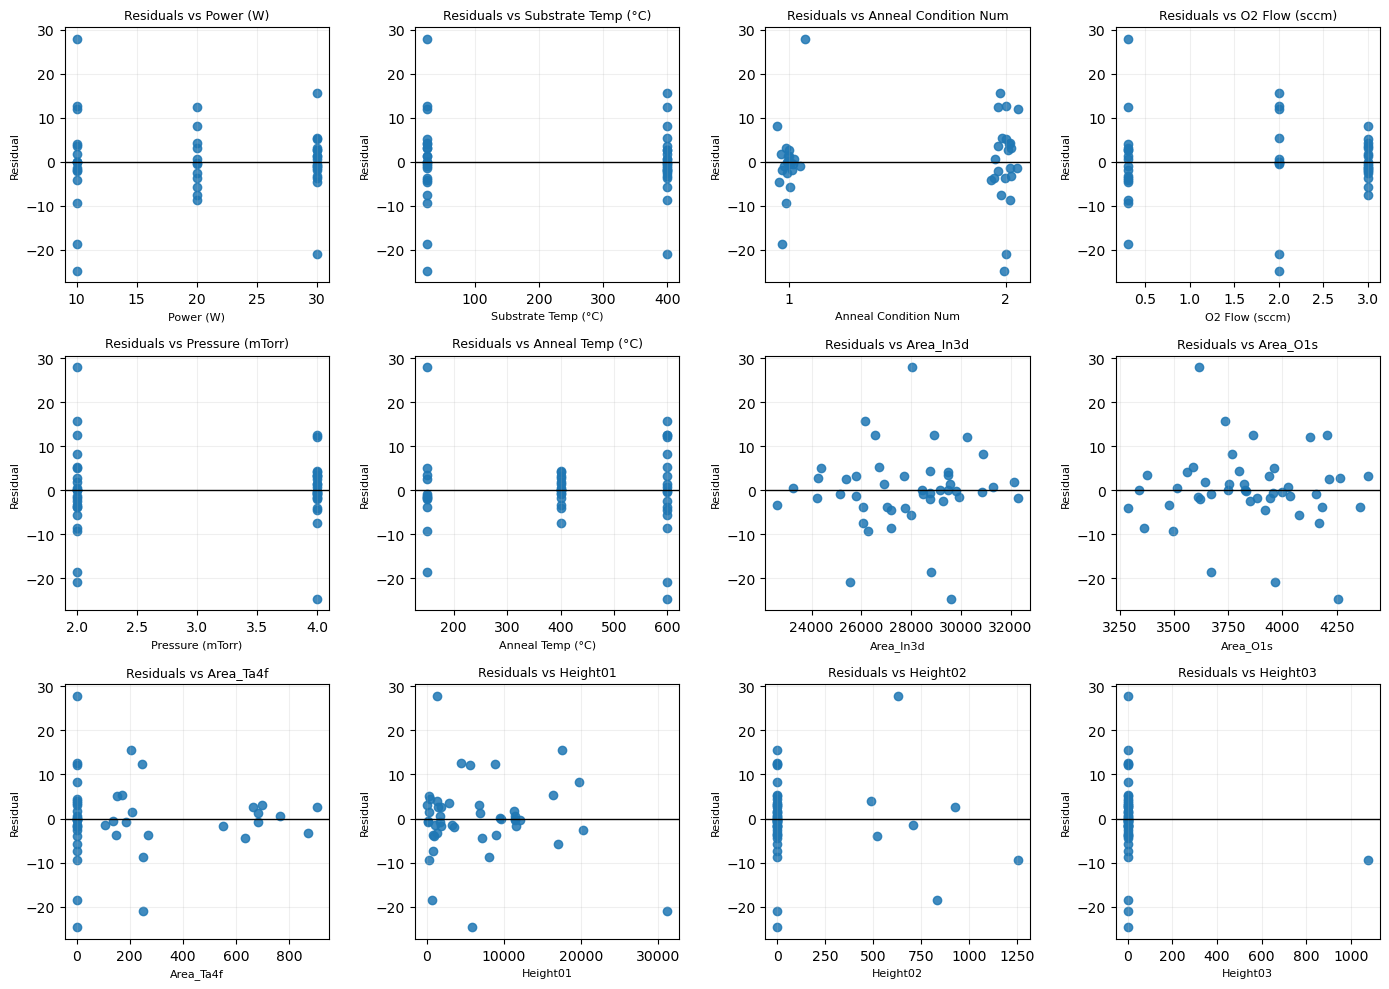

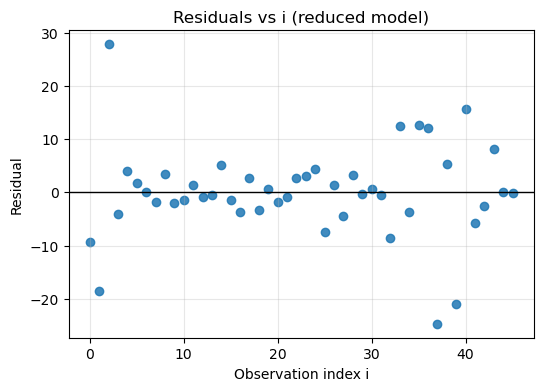

In [26]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

df_use = master_df[predictors + [target]].dropna()

# =====================================================
# Terms you decided to keep
# =====================================================
kept_terms = [
    "Anneal Condition Num",
    "Power (W)",
    "Power (W) × Anneal Condition Num",
    "Substrate Temp (°C)",
    "Substrate Temp (°C) × Anneal Condition Num",
    "O2 Flow (sccm)",
    "Anneal Condition Num × O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Power (W) × Substrate Temp (°C)",
    "Power (W) × O2 Flow (sccm)",
    "Power (W) × Pressure (mTorr)",
    "Substrate Temp (°C) × O2 Flow (sccm)",
    "Substrate Temp (°C) × Pressure (mTorr)",
    "O2 Flow (sccm) × Anneal Temp (°C)",
    "Pressure (mTorr) × Anneal Temp (°C)",
]

# Map from cleaned names to patsy expressions
name_to_patsy = {
    "Power (W)": "Q('Power (W)')",
    "Substrate Temp (°C)": "Q('Substrate Temp (°C)')",
    "Anneal Condition Num": "C(Q('Anneal Condition Num'))",
    "O2 Flow (sccm)": "Q('O2 Flow (sccm)')",
    "Pressure (mTorr)": "Q('Pressure (mTorr)')",
    "Anneal Temp (°C)": "Q('Anneal Temp (°C)')",
}

# Build main effect terms (keep all main effects from kept_terms)
main_effect_names = sorted({t for t in kept_terms if "×" not in t})
main_terms_patsy = [name_to_patsy[t] for t in main_effect_names]

# Build interaction terms in patsy syntax
interaction_names = [t for t in kept_terms if "×" in t]
interaction_terms_patsy = []
for t in interaction_names:
    left, right = [x.strip() for x in t.split("×")]
    left_patsy = name_to_patsy[left]
    right_patsy = name_to_patsy[right]
    interaction_terms_patsy.append(f"{left_patsy}:{right_patsy}")

# =====================================================
# Build reduced formula
# =====================================================
rhs_terms = main_terms_patsy + interaction_terms_patsy
formula_reduced = (
    "Q('Hall Mobility (cm^2/V·s)') ~ " + " + ".join(rhs_terms)
)

print("Reduced model formula:")
print(formula_reduced)

# =====================================================
# Fit reduced model
# =====================================================
model_red = smf.ols(formula=formula_reduced, data=df_use).fit()
print(model_red.summary())

# =====================================================
# ANOVA for reduced model (with cleaned names)
# =====================================================

def _clean_single(term: str) -> str:
    term = term.strip()
    if term.startswith("Q('") and term.endswith("')"):
        return term[3:-2]
    if term.startswith("C(Q('") and term.endswith("'))"):
        return term[5:-3]
    return term

def clean_term_name(term: str) -> str:
    if ":" in term:
        parts = term.split(":")
        clean_parts = [_clean_single(p) for p in parts]
        return " × ".join(clean_parts)
    else:
        return _clean_single(term)

anova_red = anova_lm(model_red, typ=2)
anova_red.index = [clean_term_name(t) for t in anova_red.index]

print("\n=== Reduced model ANOVA (Type II, cleaned names) ===")
print(anova_red)

# =====================================================
# Residual plots per predictor (same as before)
# =====================================================
resid = model_red.resid
pred_cols = predictors

n = len(pred_cols)
n_rows = 3
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i (reduced model)")
plt.grid(alpha=0.3)
plt.show()


# Bayesian optimization

In [27]:
import pandas as pd
import numpy as np
import torch
from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf

# columns
knob_cols = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",   # 0 or 1
    "Anneal Temp (°C)",
]
target_col = "Hall Mobility (cm^2/V·s)"

# 1) drop rows with missing knobs or missing target
df_bo = master_df[knob_cols + [target_col]].copy()
df_bo = df_bo.dropna(subset=knob_cols + [target_col])

# 2) build X and y
X = df_bo[knob_cols].astype(float).values
y = df_bo[target_col].astype(float).values.reshape(-1, 1)

# 3) normalize X to [0,1]
x_min = X.min(axis=0)
x_max = X.max(axis=0)
X_norm = (X - x_min) / (x_max - x_min + 1e-8)

# 4) make tensors
train_X = torch.tensor(X_norm, dtype=torch.double)
train_Y = torch.tensor(y, dtype=torch.double)

# 5) fit GP
model = SingleTaskGP(train_X, train_Y)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)
print("GP fitted OK, n =", train_X.shape[0])

best_f = train_Y.max()

# 2) build acquisition
q = 1  # number of points to propose at once
acqf = qExpectedImprovement(model=model, best_f=best_f)

# 3) optimize acquisition in [0, 1]^d
bounds = torch.stack(
    [
        torch.zeros(train_X.shape[1], dtype=torch.double),
        torch.ones(train_X.shape[1], dtype=torch.double),
    ]
)

candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,
)

# 4) unnormalize back to real space
candidate_np = candidate.detach().numpy()

suggestions = []
for row in candidate_np:
    # unnormalize
    real = row * (x_max - x_min) + x_min

    # round the categorical variable
    # find its index
    anneal_idx = knob_cols.index("Anneal Condition Num")
    real[anneal_idx] = round(real[anneal_idx])  # 0 or 1

    suggestions.append(dict(zip(knob_cols, real)))

# 5) print suggestions
for i, s in enumerate(suggestions, 1):
    print(f"Suggested point {i}:")
    for k, v in s.items():
        print(f"  {k}: {v:.3f}")


GP fitted OK, n = 46
Suggested point 1:
  Power (W): 16.248
  Substrate Temp (°C): 400.000
  O2 Flow (sccm): 2.455
  Pressure (mTorr): 4.000
  Anneal Condition Num: 2.000
  Anneal Temp (°C): 600.000


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:396: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


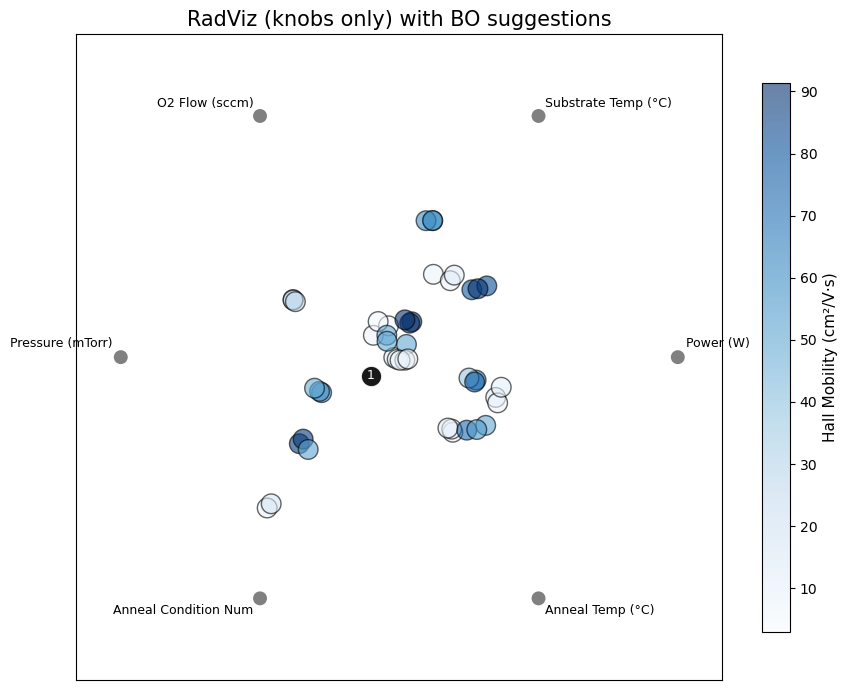

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import radviz

target_col = "Hall Mobility (cm^2/V·s)"

# -------------------------------------------------
# 1) Use only knob parameters for RadViz
# -------------------------------------------------
predictors_knobs = [
    c for c in knob_cols
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

cols_for_radviz = predictors_knobs + [target_col]
df_radviz = master_df[cols_for_radviz].dropna().copy()

# Bin Hall mobility just to satisfy pandas.radviz (we will hide these points)
df_radviz["HallMobilityBin"] = pd.qcut(
    df_radviz[target_col],
    q=3,
    labels=["Low μ", "Med μ", "High μ"],
)

df_radviz_plot = df_radviz[predictors_knobs + ["HallMobilityBin"]].copy()

# -------------------------------------------------
# 2) Optional jitter in each predictor to break ties (input space)
# -------------------------------------------------
np.random.seed(0)
jitter_strength = 0.02

for col in predictors_knobs:
    vals = df_radviz_plot[col].to_numpy(dtype=float)
    col_range = vals.max() - vals.min()
    if col_range == 0:
        continue
    noise = np.random.normal(0.0, jitter_strength * col_range, size=vals.shape)
    df_radviz_plot[col] = vals + noise

# -------------------------------------------------
# 3) Draw RadViz frame and anchors
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))
radviz(df_radviz_plot, class_column="HallMobilityBin", ax=ax)

# Remove legend created by radviz
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# Hide the class scatter that radviz drew
for coll in ax.collections:
    coll.set_alpha(0)

ax.set_title("RadViz (knobs only) with BO suggestions", fontsize=15)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

# Pull text labels slightly outward and shrink font
for txt in ax.texts:
    x, y = txt.get_position()
    r = np.sqrt(x**2 + y**2)
    if r > 0:
        new_r = 1.03
        scale = new_r / r
        txt.set_position((x * scale, y * scale))
        txt.set_fontsize(9)

# -------------------------------------------------
# 4) Compute RadViz coordinates for existing data
# -------------------------------------------------
X = df_radviz[predictors_knobs].to_numpy(dtype=float)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1.0
X_norm = (X - X_min) / X_range

n_samples, n_features = X_norm.shape
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False)
anchors = np.stack([np.cos(angles), np.sin(angles)], axis=1)

den = X_norm.sum(axis=1)
den[den == 0] = 1e-12
coords = (X_norm @ anchors) / den[:, None]

x_rv = coords[:, 0]
y_rv = coords[:, 1]
hall_vals = df_radviz[target_col].to_numpy(dtype=float)

# ---------- NEW: jitter in RadViz coordinates for background points ----------
rng_bg = np.random.default_rng(123)
rv_jitter = 0.02  # adjust if you want more / less spread
x_rv_j = x_rv + rng_bg.normal(0.0, rv_jitter, size=x_rv.shape)
y_rv_j = y_rv + rng_bg.normal(0.0, rv_jitter, size=y_rv.shape)

# Continuous Hall mobility background
sc = ax.scatter(
    x_rv_j,
    y_rv_j,
    c=hall_vals,
    cmap="Blues",
    s=200,
    alpha=0.6,
    edgecolor="k",
    zorder=2,
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Hall Mobility (cm²/V·s)", fontsize=11)

# -------------------------------------------------
# 5) Overlay BO suggested points as black dots
# -------------------------------------------------
suggest_df = pd.DataFrame(suggestions)

# Keep only the knob columns used in RadViz
cand_X = suggest_df[predictors_knobs].astype(float).to_numpy()

cand_norm = (cand_X - X_min) / X_range
den_cand = cand_norm.sum(axis=1)
den_cand[den_cand == 0] = 1e-12
coords_cand = (cand_norm @ anchors) / den_cand[:, None]

x_cand = coords_cand[:, 0]
y_cand = coords_cand[:, 1]

# ---------- NEW: small jitter for suggested points too ----------
rng_cand = np.random.default_rng(456)
cand_jitter = 0.015
x_cand_j = x_cand + rng_cand.normal(0.0, cand_jitter, size=x_cand.shape)
y_cand_j = y_cand + rng_cand.normal(0.0, cand_jitter, size=y_cand.shape)

ax.scatter(
    x_cand_j,
    y_cand_j,
    c="k",
    s=220,
    alpha=0.9,
    edgecolor="white",
    linewidths=1.0,
    zorder=5,
)

# Optional: label suggested points 1, 2, 3
for i, (xc, yc) in enumerate(zip(x_cand_j, y_cand_j), start=1):
    ax.text(
        xc,
        yc,
        str(i),
        color="white",
        fontsize=9,
        ha="center",
        va="center",
        zorder=6,
    )

plt.tight_layout()
plt.show()


# LVGP

In [29]:
print(master_df.columns.tolist())

['Experiment', 'Trial', 'Anneal Condition Num', 'Power (W)', 'Substrate Temp (°C)', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Condition', 'Anneal Temp (°C)', 'Hall Mobility (cm^2/V·s)', 'Hall mobility raw', 'Hall mobility status', 'In3d_p1', 'In3d_p2', 'O1s_p1', 'Ta4f_p1', 'Ta4f_p2', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'In3d01', 'In3d02', 'In3d status', 'O1s', 'Ta4f01', 'Ta4f02', 'Ta4f status', 'Area Ta4f raw', 'Area Ta4f status', 'Peak01', 'Peak02', 'Peak03', 'Height01', 'Height02', 'Height03', 'FWHM01', 'FWHM02', 'FWHM03', 'Peak position raw', 'Height raw', 'FWHM raw', 'XRD status']


In [30]:
import pandas as pd
import numpy as np
import torch

from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll

knob_cols = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",   # 0 or 1
    "Anneal Temp (°C)",
]
target_col = "Hall Mobility (cm^2/V·s)"

# 1) Clean data: drop rows with missing knobs or target
df_bo = master_df[knob_cols + [target_col]].copy()
df_bo = df_bo.dropna(subset=knob_cols + [target_col])

# Make sure anneal condition is 0/1 numeric
df_bo["Anneal Condition Num"] = df_bo["Anneal Condition Num"].astype(float)

# 2) Build X and y
X = df_bo[knob_cols].values.astype(float)
y = df_bo[target_col].values.astype(float).reshape(-1, 1)

# 3) Normalize X to [0,1] for each dimension
x_min = X.min(axis=0)
x_max = X.max(axis=0)
X_norm = (X - x_min) / (x_max - x_min + 1e-8)

train_X = torch.tensor(X_norm, dtype=torch.double)
train_Y = torch.tensor(y, dtype=torch.double)

# 4) Fit GP
model = SingleTaskGP(train_X, train_Y)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

print("GP fitted, n =", train_X.shape[0])


GP fitted, n = 46


In [31]:
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf

# 1) Best Hall mobility observed so far
best_f = train_Y.max()

# 2) EI acquisition function
acqf = qExpectedImprovement(model=model, best_f=best_f)

d = train_X.shape[1]  # number of inputs
bounds = torch.stack(
    [torch.zeros(d, dtype=torch.double),
     torch.ones(d, dtype=torch.double)]
)

# 3) Optimize EI in [0,1]^d (continuous)
q = 4  # number of points to suggest
candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,
)
print(candidate)
# 4) Unnormalize to real units
candidate_np = candidate.detach().numpy()[0]
suggested = candidate_np * (x_max - x_min) + x_min

# 5) Round ONLY the anneal condition to 0 or 1
anneal_idx = knob_cols.index("Anneal Condition Num")
suggested[anneal_idx] = round(suggested[anneal_idx])  # 0 or 1

# 6) Pack suggestions in a readable dict
suggestion = dict(zip(knob_cols, suggested))

print("Suggested next experiment:")
for k, v in suggestion.items():
    print(f"  {k}: {v:.3f}")


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:396: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


tensor([[0.2088, 0.5481, 0.9453, 1.0000, 0.0000, 1.0000],
        [0.7554, 0.9074, 0.9225, 0.4285, 0.7243, 0.9757],
        [0.3142, 1.0000, 0.7140, 0.0000, 1.0000, 1.0000],
        [0.3235, 1.0000, 0.8421, 1.0000, 1.0000, 1.0000]], dtype=torch.float64)
Suggested next experiment:
  Power (W): 14.176
  Substrate Temp (°C): 230.540
  O2 Flow (sccm): 2.852
  Pressure (mTorr): 4.000
  Anneal Condition Num: 1.000
  Anneal Temp (°C): 600.000


# Trees 

In [32]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error

# -------------------------------
# 0) Same setup as your OLS code
# -------------------------------
predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical (treated as numeric codes here)
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

exclude_for_model = {
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
    # you currently keep "Anneal Condition Num" in the model
}

# build clean df
df_use = master_df[predictors + [target]].dropna()

# ------------------------------------------
# 1) Select features
# ------------------------------------------
feature_cols = [col for col in predictors if col not in exclude_for_model]
X = df_use[feature_cols].values
y = df_use[target].values

print("Features used:", feature_cols)

# ------------------------------------------
# 2) Fit regression tree on ALL data
# ------------------------------------------
tree_reg = DecisionTreeRegressor(
    max_depth=3,        # tweak as you like
    min_samples_leaf=3,
    random_state=0,
)
tree_reg.fit(X, y)

# ------------------------------------------
# 3) In-sample performance
# ------------------------------------------
y_pred = tree_reg.predict(X)

rmse_in = root_mean_squared_error(y, y_pred)
r2_in = r2_score(y, y_pred)

print(f"In-sample RMSE = {rmse_in:.3f}")
print(f"In-sample R²   = {r2_in:.3f}")

# ------------------------------------------
# 4) Cross-validated performance (no explicit test split)
# ------------------------------------------
cv_r2 = cross_val_score(tree_reg, X, y, cv=5, scoring="r2")
cv_rmse = -cross_val_score(
    tree_reg, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("\nCV R² (5-fold):", np.round(cv_r2, 3), " | mean =", cv_r2.mean().round(3))
print("CV RMSE (5-fold):", np.round(cv_rmse, 3), " | mean =", cv_rmse.mean().round(3))

# ------------------------------------------
# 5) Feature importances
# ------------------------------------------
importances = tree_reg.feature_importances_
imp_df = pd.DataFrame(
    {"feature": feature_cols, "importance": importances}
).sort_values("importance", ascending=False)

print("\nFeature importances")
print(imp_df.to_string(index=False))


Features used: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)']
In-sample RMSE = 11.255
In-sample R²   = 0.861

CV R² (5-fold): [ -0.154 -32.863   0.178  -0.204  -2.497]  | mean = -7.108
CV RMSE (5-fold): [23.261 35.379 20.093 28.233 32.095]  | mean = 27.812

Feature importances
             feature  importance
           Power (W)    0.428956
    Anneal Temp (°C)    0.344737
      O2 Flow (sccm)    0.121893
Anneal Condition Num    0.104414
 Substrate Temp (°C)    0.000000
    Pressure (mTorr)    0.000000


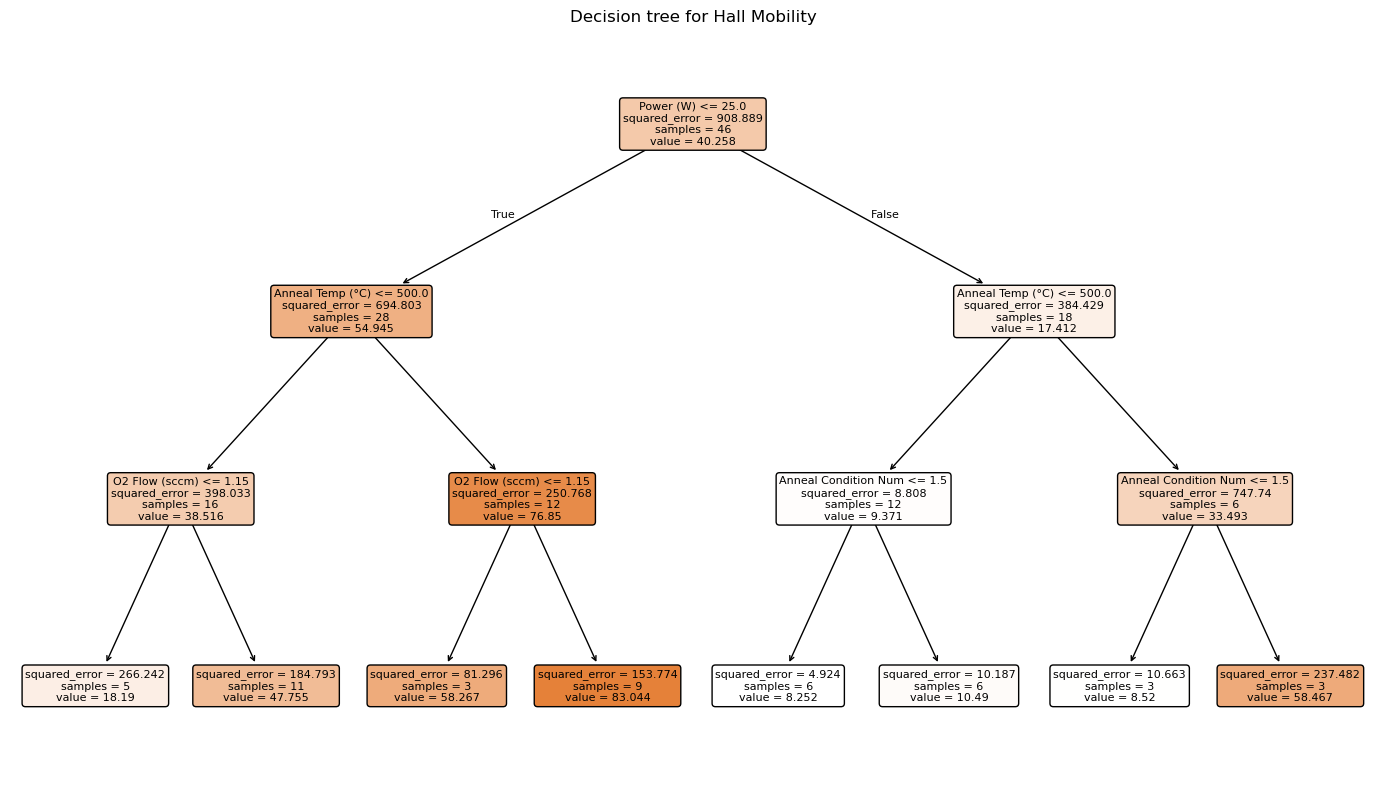

In [33]:
import matplotlib.pyplot as plt
from sklearn import tree

# ------------------------------------------
# Plot the decision tree
# ------------------------------------------
plt.figure(figsize=(14, 8))

tree.plot_tree(
    tree_reg,
    feature_names=feature_cols,
    filled=True,          # color leaves by value
    rounded=True,
    fontsize=8
)

plt.title("Decision tree for Hall Mobility")
plt.tight_layout()
plt.show()


Number of candidate alphas: 12

CPTABLE (like rpart$cptable):
     alpha  n_leaves  depth   cv_rmse  rel_error
  0.000000        14      5 34.219204   1.084506
  0.013636        14      5 35.637433   1.129454
  0.335589        11      5 34.249452   1.085465
  1.850580        11      5 34.371289   1.089326
  2.077973         9      4 34.959695   1.107974
  6.019758         9      4 35.719233   1.132046
 30.029589         7      4 34.371289   1.089326
 38.627142         6      3 35.719233   1.132046
 65.317159         5      3 31.552801   1.000000
 65.973742         3      2 31.552801   1.000000
219.059524         2      1 35.467571   1.124070
335.537357         1      0 38.094588   1.207328

Best alpha (min CV RMSE): 65.317159, leaves = 5, cv_rmse = 31.553


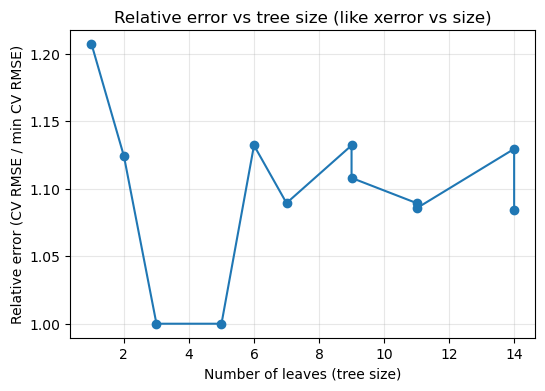

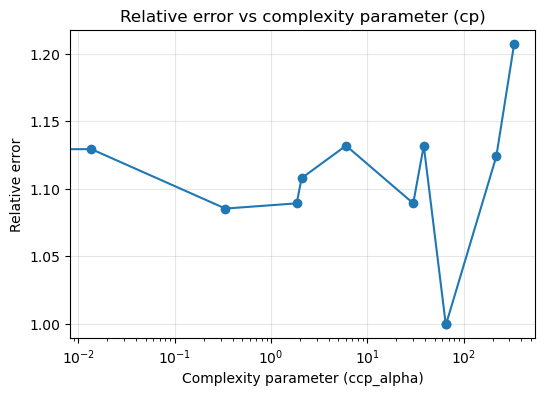

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

# ------------------------------------------
# 0) Cost-complexity pruning path
# ------------------------------------------
base_tree = DecisionTreeRegressor(
    random_state=0,
    min_samples_leaf=3,
    # do NOT set max_depth here, let pruning control complexity
)

path = base_tree.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas  # like cp in rpart
impurities = path.impurities

print("Number of candidate alphas:", len(ccp_alphas))

# ------------------------------------------
# 1) Fit a tree for each alpha and do CV
# ------------------------------------------
trees = []
cv_rmse_list = []
n_leaves_list = []
depth_list = []

for alpha in ccp_alphas:
    tree_reg = DecisionTreeRegressor(
        # random_state=15,
        min_samples_leaf=3,
        ccp_alpha=alpha,
    )
    # 5-fold CV RMSE
    cv_rmse = -cross_val_score(
        tree_reg,
        X,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error",
    )
    cv_rmse_list.append(cv_rmse.mean())

    tree_reg.fit(X, y)
    trees.append(tree_reg)
    n_leaves = np.sum(tree_reg.tree_.children_left == -1)
    n_leaves_list.append(n_leaves)
    depth_list.append(tree_reg.get_depth())

cv_rmse_array = np.array(cv_rmse_list)

# relative error: CV RMSE relative to the *smallest* CV RMSE
best_rmse = cv_rmse_array.min()
rel_error = cv_rmse_array / best_rmse

# ------------------------------------------
# 2) Build a cptable-like summary
# ------------------------------------------
cptable = pd.DataFrame({
    "alpha": ccp_alphas,
    "n_leaves": n_leaves_list,
    "depth": depth_list,
    "cv_rmse": cv_rmse_array,
    "rel_error": rel_error,
})

# find best (min CV error)
best_idx = np.argmin(cv_rmse_array)
best_alpha = ccp_alphas[best_idx]
best_n_leaves = n_leaves_list[best_idx]

print("\nCPTABLE (like rpart$cptable):")
print(cptable.head(15).to_string(index=False))  # show first 15 rows

print(f"\nBest alpha (min CV RMSE): {best_alpha:.6f}, "
      f"leaves = {best_n_leaves}, "
      f"cv_rmse = {best_rmse:.3f}")

# ------------------------------------------
# 3) Plots similar to R: relative error vs size and vs cp
# ------------------------------------------

# (a) relative error vs number of leaves
plt.figure(figsize=(6, 4))
plt.plot(n_leaves_list, rel_error, marker="o")
plt.xlabel("Number of leaves (tree size)")
plt.ylabel("Relative error (CV RMSE / min CV RMSE)")
plt.title("Relative error vs tree size (like xerror vs size)")
plt.grid(alpha=0.3)
plt.show()

# (b) relative error vs complexity parameter alpha
plt.figure(figsize=(6, 4))
plt.plot(ccp_alphas, rel_error, marker="o")
plt.xlabel("Complexity parameter (ccp_alpha)")
plt.ylabel("Relative error")
plt.title("Relative error vs complexity parameter (cp)")
plt.grid(alpha=0.3)
plt.xscale("log")  # cp / alpha often looks better on log scale
plt.show()


Best-pruned tree:
  n_leaves: 5
  depth   : 3
R² (on all data) = 0.755


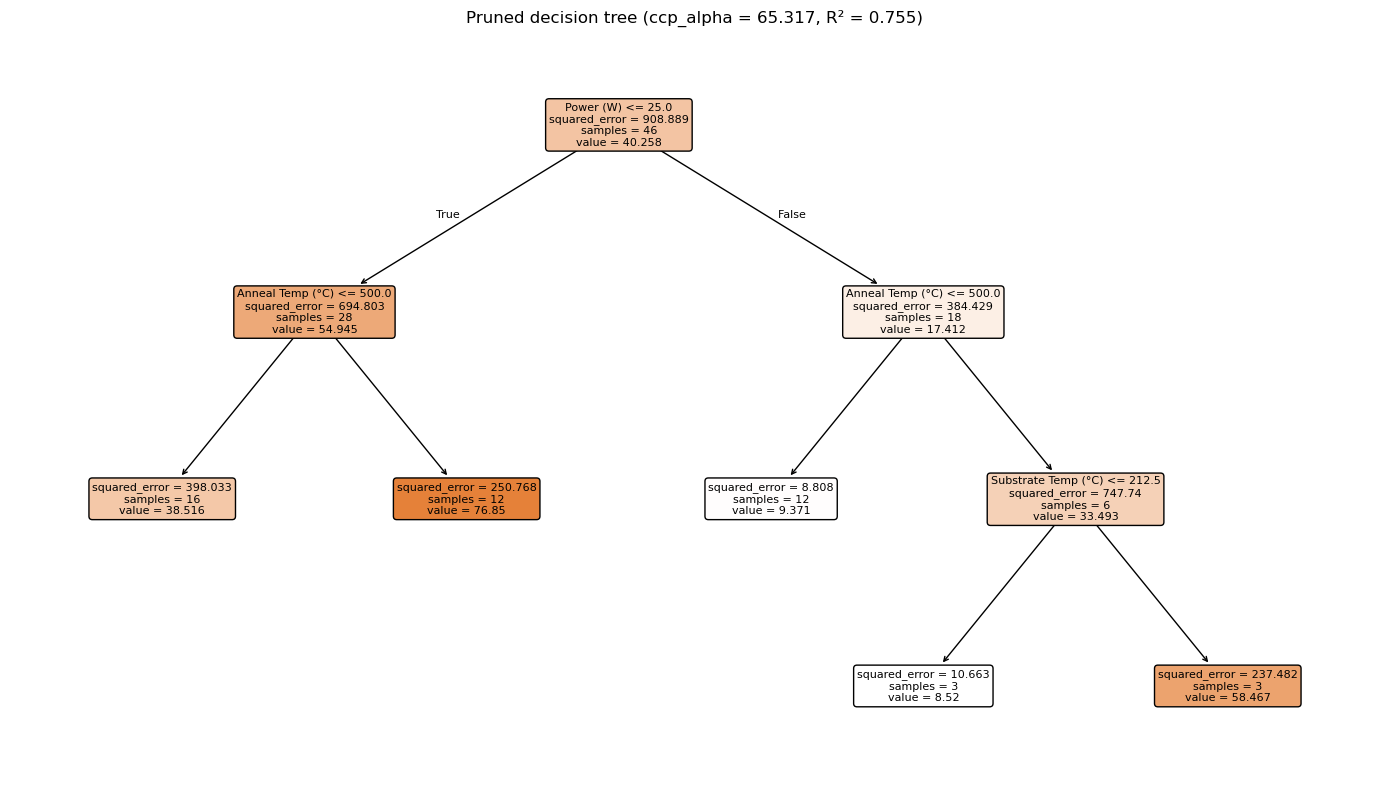


Feature importances:
             feature  importance
           Power (W)    0.488734
    Anneal Temp (°C)    0.392777
 Substrate Temp (°C)    0.118489
Anneal Condition Num    0.000000
      O2 Flow (sccm)    0.000000
    Pressure (mTorr)    0.000000


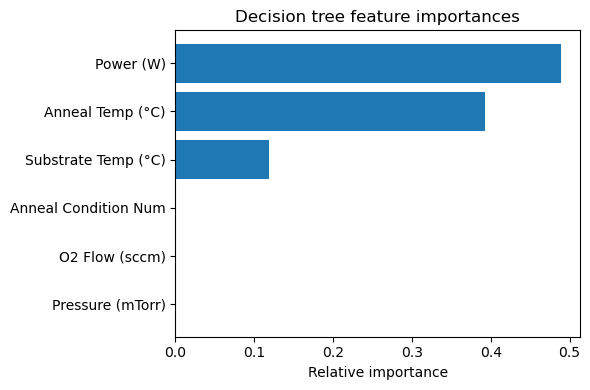

In [35]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.metrics import r2_score

# -------------------------------
# 1) Refit the best-pruned tree
# -------------------------------
best_alpha = 0  # or use the value you printed from cptable

# tree_best = DecisionTreeRegressor(
#     random_state=0,
#     min_samples_leaf=3,
#     ccp_alpha=best_alpha,
# )

best_tree = trees[best_idx]

# use the selected best tree and refit on all data
tree_best = best_tree
# tree_best.fit(X, y)

print("Best-pruned tree:")
print("  n_leaves:", np.sum(tree_best.tree_.children_left == -1))
print("  depth   :", tree_best.get_depth())

# ---- R² on all data ----
y_pred = tree_best.predict(X)
r2 = r2_score(y, y_pred)
print(f"R² (on all data) = {r2:.3f}")

# -------------------------------
# 2) Plot the pruned tree
# -------------------------------
plt.figure(figsize=(14, 8))

tree.plot_tree(
    tree_best,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    f"Pruned decision tree (ccp_alpha = {tree_best.ccp_alpha:.3f}, R² = {r2:.3f})"
)
plt.tight_layout()
plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) Get importances
importances = tree_best.feature_importances_   # one value per feature
imp_df = pd.DataFrame(
    {"feature": feature_cols, "importance": importances}
).sort_values("importance", ascending=False)

print("\nFeature importances:")
print(imp_df.to_string(index=False))

# 2) (Optional) Bar plot
plt.figure(figsize=(6, 4))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.gca().invert_yaxis()  # most important on top
plt.xlabel("Relative importance")
plt.title("Decision tree feature importances")
plt.tight_layout()
plt.show()


In [36]:
print(trees[best_idx].ccp_alpha)

65.31715915266776
